# TCGA-BRCA Comprehensive Bioinformatics Analysis Pipeline

## Overview
This notebook analyzes The Cancer Genome Atlas (TCGA) Breast Cancer (BRCA) datasets including:
- **Gene Expression**: RNA-seq STAR TPM (Transcripts Per Million) data - log2(TPM+1) transformed
- **Clinical Data**: Overall survival (OS) time and event status
- **Molecular Subtypes**: PAM50 intrinsic subtypes (Luminal A, Luminal B, Basal, HER2, Normal-like)

## Analysis Workflow
1. **Data Loading & Validation** - Load and validate all input files
2. **Quality Control** - Check data integrity, remove low-quality genes
3. **Descriptive Statistics** - Calculate gene-level summary statistics
4. **Correlation Analysis** - Identify gene-gene associations, including subtype-specific correlations
5. **Regression Models** - Predict gene expression using other genes
6. **Dimensionality Reduction** - PCA to visualize sample relationships
7. **Clustering** - Unsupervised grouping using multiple methods
8. **Machine Learning** - Supervised PAM50 subtype classification
9. **Survival Analysis** - Association between gene expression and patient outcomes
10. **Deep Learning** - Autoencoders and neural networks for advanced analysis

## Expected Outcomes
- Identified biomarker genes
- Subtype-specific biological insights
- Predictive machine learning models
- Publication-ready visualizations
- Comprehensive analysis report

## Environment Setup
Import all required libraries and configure settings for reproducible analysis.

In [1]:
# Core libraries
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import skew, kurtosis

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report,
                             silhouette_score, adjusted_rand_score, ConfusionMatrixDisplay)
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Settings
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Optional packages
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed. Install with: pip install xgboost")

try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.statistics import logrank_test
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠️  Lifelines not installed. Survival analysis will be skipped. Install with: pip install lifelines")

ENSORFLOW_AVAILABLE = False
print("⚠️ TensorFlow disabled for now. Deep learning will be skipped.")
try:
    import torch
    PYTORCH_AVAILABLE = True
except ImportError:
    PYTORCH_AVAILABLE = False

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("✓ Environment setup complete!")

⚠️ TensorFlow disabled for now. Deep learning will be skipped.
✓ Environment setup complete!


## File Path Validation
Define and validate all input file paths. The notebook expects files in WSL-compatible format.

In [2]:
# Define file paths (WSL-compatible)
BASE_DIR = Path("/mnt/c/TCGA_cancer")
EXPRESSION_FILE = BASE_DIR / "TCGA-BRCA.star_tpm.tsv"
SURVIVAL_FILE = BASE_DIR / "TCGA-BRCA.survival.tsv"
PAM50_DIR = BASE_DIR / "brca_pam50"

print("📁 File Path Validation")
print("=" * 60)
print(f"Base directory: {BASE_DIR}")
print()

# Check if base directory exists
if not BASE_DIR.exists():
    print(f"❌ ERROR: Base directory does not exist: {BASE_DIR}")
    print(f"   Please ensure your data directory is at {BASE_DIR}")
    sys.exit(1)

# Check expression file
if EXPRESSION_FILE.exists():
    file_size_mb = EXPRESSION_FILE.stat().st_size / (1024**2)
    print(f"✓ Expression file found: {EXPRESSION_FILE.name} ({file_size_mb:.1f} MB)")
else:
    print(f"❌ Expression file NOT found: {EXPRESSION_FILE}")
    print(f"   This file is REQUIRED for the analysis")
    sys.exit(1)

# Check survival file
if SURVIVAL_FILE.exists():
    print(f"✓ Survival file found: {SURVIVAL_FILE.name}")
    SURVIVAL_AVAILABLE = True
else:
    print(f"⚠️  Survival file NOT found: {SURVIVAL_FILE} (optional)")
    SURVIVAL_AVAILABLE = False

# Check PAM50 data
if PAM50_DIR.exists():
    if PAM50_DIR.is_dir():
        # List files in directory
        files = list(PAM50_DIR.glob("*.tsv")) + list(PAM50_DIR.glob("*.csv")) + \
                list(PAM50_DIR.glob("*.txt")) + list(PAM50_DIR.glob("*.gz"))
        if files:
            print(f"✓ PAM50 directory found with {len(files)} file(s):")
            for f in files[:5]:  # Show first 5
                print(f"    - {f.name}")
            PAM50_AVAILABLE = True
        else:
            print(f"⚠️  PAM50 directory exists but is empty: {PAM50_DIR}")
            PAM50_AVAILABLE = False
    else:
        # It's a file
        print(f"✓ PAM50 file found: {PAM50_DIR.name}")
        PAM50_AVAILABLE = True
else:
    print(f"⚠️  PAM50 data NOT found: {PAM50_DIR} (optional)")
    PAM50_AVAILABLE = False

print()
print("=" * 60)
print("Status: Ready to proceed with analysis")

📁 File Path Validation
Base directory: /mnt/c/TCGA_cancer

✓ Expression file found: TCGA-BRCA.star_tpm.tsv (854.1 MB)
✓ Survival file found: TCGA-BRCA.survival.tsv
✓ PAM50 file found: brca_pam50

Status: Ready to proceed with analysis


## Output Directory Structure
Create organized output folders for results, figures, tables, and models.

In [3]:
# Create output directory structure
RESULTS_DIR = BASE_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
NOTEBOOK_OUTPUTS_DIR = RESULTS_DIR / "notebook_outputs"

# Create all directories
for directory in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, NOTEBOOK_OUTPUTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
    print(f"✓ Created/confirmed: {directory.relative_to(BASE_DIR)}/")

print(f"\n✓ All output directories ready at: {RESULTS_DIR}/")
print(f"  ├── tables/")
print(f"  ├── figures/")
print(f"  ├── models/")
print(f"  └── notebook_outputs/")

✓ Created/confirmed: results/
✓ Created/confirmed: results/tables/
✓ Created/confirmed: results/figures/
✓ Created/confirmed: results/models/
✓ Created/confirmed: results/notebook_outputs/

✓ All output directories ready at: /mnt/c/TCGA_cancer/results/
  ├── tables/
  ├── figures/
  ├── models/
  └── notebook_outputs/


## Section 1: Load Gene Expression Data
Read and validate RNA-seq STAR TPM expression matrix.

In [4]:
print("Loading gene expression data...")
print(f"File: {EXPRESSION_FILE.name}")
print()

# Read expression matrix with auto-detection of separator
try:
    # Try tab-separated first
    expr_df = pd.read_csv(EXPRESSION_FILE, sep='\t', index_col=0)
    sep = '\t'
except:
    # Try comma-separated
    expr_df = pd.read_csv(EXPRESSION_FILE, sep=',', index_col=0)
    sep = ','

print(f"✓ Detected separator: {repr(sep)}")
print(f"✓ Initial shape: {expr_df.shape} (rows × columns)")
print()

# Check if transpose is needed (if genes are rows, samples are columns)
if expr_df.shape[0] > expr_df.shape[1]:  # More rows than columns
    print("✓ Matrix has more rows than columns")
    print("  Transposing to make samples=rows, genes=columns...")
    expr_df = expr_df.T
    print(f"  New shape: {expr_df.shape}")
else:
    print("✓ Matrix orientation correct (samples=rows, genes=columns)")

print()
print("First 5 rows:")
display(expr_df.head())

print(f"\nData type: {expr_df.dtypes.unique()}")
print(f"Expression range: [{expr_df.min().min():.2f}, {expr_df.max().max():.2f}]")
print("\n✓ NOTE: Data is already log2(TPM+1) transformed. No further log transformation needed.")

# Store in global variable
expr = expr_df.copy()
original_n_genes = expr.shape[1]
original_n_samples = expr.shape[0]
print(f"\n✓ Loaded: {original_n_samples} samples × {original_n_genes} genes")

Loading gene expression data...
File: TCGA-BRCA.star_tpm.tsv

✓ Detected separator: '\t'
✓ Initial shape: (60660, 1226) (rows × columns)

✓ Matrix has more rows than columns
  Transposing to make samples=rows, genes=columns...
  New shape: (1226, 60660)

First 5 rows:


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,ENSG00000001460.18,ENSG00000001461.17,ENSG00000001497.18,ENSG00000001561.7,ENSG00000001617.12,ENSG00000001626.16,ENSG00000001629.10,ENSG00000001630.17,ENSG00000001631.16,ENSG00000002016.18,ENSG00000002079.14,ENSG00000002330.14,ENSG00000002549.12,ENSG00000002586.20,ENSG00000002586.20_PAR_Y,...,ENSG00000288639.1,ENSG00000288640.1,ENSG00000288642.1,ENSG00000288643.1,ENSG00000288644.1,ENSG00000288645.1,ENSG00000288646.1,ENSG00000288648.1,ENSG00000288649.1,ENSG00000288654.1,ENSG00000288656.1,ENSG00000288657.1,ENSG00000288658.1,ENSG00000288659.1,ENSG00000288660.1,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,2.422852,3.982683,4.229911,5.159799,6.495988,0.101650,5.801014,2.527371,2.609329,3.341772,0.101919,4.649202,6.613084,7.653464,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.094506,0.0,0.151989,0.0,0.125254,0.0,0.0,0.537346,0.0,0.000000,0.0,3.533999,0.0,0.058109,1.122739
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,2.331562,4.020476,4.270118,4.645073,6.239948,0.262794,5.487473,1.544683,2.141465,2.697507,0.122474,3.841842,6.084636,7.470085,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.022758,0.0,0.972619,0.0,0.000000,0.0,0.0,0.204767,0.0,0.000000,0.0,4.773448,0.0,0.054779,1.243182
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,2.346503,3.692695,4.114225,3.935714,6.084949,0.084200,5.599502,1.970743,2.316580,2.774629,0.121015,3.881165,6.669529,6.186435,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.056445,0.0,0.0,0.016924,0.0,0.389677,0.0,0.171847,0.0,0.0,0.412402,0.0,0.000000,0.0,4.701710,0.0,0.093425,0.604261
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,2.696728,3.766500,4.349613,4.797122,6.701058,0.074094,5.230703,2.152573,1.902575,2.735544,0.039419,2.094439,7.443983,6.845449,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.160533,0.0,0.000000,0.0,0.0,0.268075,0.0,0.966357,0.0,4.689075,0.0,0.059771,0.536351
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,2.253899,4.828809,4.347481,5.721006,7.813244,0.040121,5.426184,0.931229,2.040717,2.823077,0.147697,2.363367,5.792108,4.760029,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.014784,0.0,1.312200,0.0,0.077243,0.0,0.0,0.434028,0.0,0.000000,0.0,5.168221,0.0,0.023752,0.389126



Data type: [dtype('float64')]
Expression range: [0.00, 18.79]

✓ NOTE: Data is already log2(TPM+1) transformed. No further log transformation needed.

✓ Loaded: 1226 samples × 60660 genes


## Section 2: Load Clinical Survival Data
Load and validate overall survival (OS) and event status information.

In [5]:
surv = None
time_col = None
event_col = None

if SURVIVAL_AVAILABLE:
    print("Loading survival data...")
    try:
        surv = pd.read_csv(SURVIVAL_FILE, sep='\t', index_col=0)
    except:
        surv = pd.read_csv(SURVIVAL_FILE, sep=',', index_col=0)
    
    print(f"✓ Shape: {surv.shape}")
    print(f"✓ Columns: {list(surv.columns)[:10]}")  # Show first 10
    print()
    print("First 5 rows:")
    display(surv.head())
    
    # Auto-detect survival columns
    for col in surv.columns:
        col_lower = col.lower()
        if time_col is None and ('time' in col_lower):
            time_col = col
        if event_col is None and ('event' in col_lower or 'status' in col_lower):
            event_col = col
    
    if time_col and event_col:
        print(f"\n✓ Detected OS time column: {time_col}")
        print(f"✓ Detected OS event column: {event_col}")
    else:
        print(f"\n⚠️  Could not auto-detect survival columns")
        time_col = surv.columns[1] if len(surv.columns) > 1 else None
        event_col = surv.columns[2] if len(surv.columns) > 2 else None
        print(f"  Using: time={time_col}, event={event_col}")
else:
    print("⚠️  Survival data not available - survival analysis will be skipped")

Loading survival data...
✓ Shape: (1232, 3)
✓ Columns: ['OS.time', 'OS', '_PATIENT']

First 5 rows:


,OS.time,OS,_PATIENT
sample,,,
TCGA-C8-A275-01A,1.0,0,TCGA-C8-A275
TCGA-AC-A7VC-01A,1.0,0,TCGA-AC-A7VC
TCGA-BH-A1F8-01A,1.0,1,TCGA-BH-A1F8
TCGA-BH-A1F8-11B,1.0,1,TCGA-BH-A1F8
TCGA-PL-A8LX-01A,5.0,0,TCGA-PL-A8LX



⚠️  Could not auto-detect survival columns
  Using: time=OS, event=_PATIENT


## Section 3: Load PAM50 Molecular Subtypes
Load breast cancer molecular subtype classifications (Luminal A/B, HER2+, Basal-like).

In [6]:
pam50 = None

if PAM50_AVAILABLE:
    print("Loading PAM50 molecular subtype data...")
    
    # Find PAM50 file
    pam50_files = list(PAM50_DIR.glob("*.tsv")) + list(PAM50_DIR.glob("*.csv")) + \
                  list(PAM50_DIR.glob("*.txt"))
    
    if not pam50_files and PAM50_DIR.is_file():
        # PAM50_DIR is actually a file
        pam50_files = [PAM50_DIR]
    
    if pam50_files:
        pam50_file = pam50_files[0]
        print(f"✓ Found: {pam50_file.name}")
        
        # Auto-detect separator
        try:
            pam50 = pd.read_csv(pam50_file, sep='\t', index_col=0)
        except:
            try:
                pam50 = pd.read_csv(pam50_file, sep=',', index_col=0)
            except:
                pam50 = pd.read_csv(pam50_file, sep=' ', index_col=0)
        
        print(f"✓ Shape: {pam50.shape}")
        print(f"✓ Columns: {list(pam50.columns)}")
        print()
        print("First 5 rows:")
        display(pam50.head())
        
        # Get subtype column
        if 'subtype' in pam50.columns:
            subtype_col = 'subtype'
        elif 'PAM50' in pam50.columns:
            subtype_col = 'PAM50'
        else:
            subtype_col = pam50.columns[0]
        
        print(f"\n✓ Subtype distribution:")
        print(pam50[subtype_col].value_counts())
    else:
        print("⚠️  No PAM50 files found in directory")
else:
    print("⚠️  PAM50 data not available - subtype analysis will be skipped")

Loading PAM50 molecular subtype data...
✓ Found: brca_pam50
✓ Shape: (141, 1)
✓ Columns: ['PAM50']

First 5 rows:


,PAM50
sample,
TCGA-A7-A13F-01A,LumB
TCGA-A7-A13F-01A,LumB
TCGA-A7-A13E-01A,Basal
TCGA-A7-A13E-01A,Basal
TCGA-BH-A0DP-01A,LumA



✓ Subtype distribution:
PAM50
LumB       47
LumA       34
Basal      30
Her2       22
Unknown     7
Normal      1
Name: count, dtype: int64


## Section 4: Data Quality Control & Sample Matching
Harmonize sample IDs and filter for complete cases across all datasets.

In [7]:
print("Data Quality Control & Sample Matching")
print("=" * 60)

# Convert sample IDs to TCGA barcode format (first 12 chars: TCGA-XX-XXXX)
def normalize_sample_id(s):
    """Extract TCGA barcode (first 12 characters of full sample ID)"""
    s_str = str(s).split('|')[0] if '|' in str(s) else str(s)
    return s_str[:12] if len(s_str) >= 12 else s_str

expr.index = expr.index.map(normalize_sample_id)
print(f"✓ Normalized expression sample IDs")

if surv is not None:
    surv.index = surv.index.map(normalize_sample_id)
    print(f"✓ Normalized survival sample IDs")

if pam50 is not None:
    pam50.index = pam50.index.map(normalize_sample_id)
    print(f"✓ Normalized PAM50 sample IDs")

# Find common samples across all datasets
expr_samples = set(expr.index)
surv_samples = set(surv.index) if surv is not None else expr_samples
pam50_samples = set(pam50.index) if pam50 is not None else expr_samples

common_samples = expr_samples & surv_samples & pam50_samples
print()
print(f"Expression samples: {len(expr_samples)}")
print(f"Survival samples: {len(surv_samples)}")
print(f"PAM50 samples: {len(pam50_samples)}")
print(f"✓ Common samples across all datasets: {len(common_samples)}")

# Filter to common samples
expr = expr.loc[list(common_samples)].copy()
if surv is not None:
    surv = surv.loc[list(common_samples)].copy()
if pam50 is not None:
    pam50 = pam50.loc[list(common_samples)].copy()

print(f"✓ Filtered expression matrix: {expr.shape}")

# Check for missing values
missing_expr = expr.isna().sum().sum()
missing_surv = 0 if surv is None else surv.isna().sum().sum()
print()
print(f"Missing values in expression: {missing_expr} ({missing_expr/expr.size*100:.2f}%)")
if surv is not None:
    print(f"Missing values in survival: {missing_surv} ({missing_surv/surv.size*100:.2f}%)")

# Remove genes with very low variance
initial_genes = expr.shape[1]
variance_threshold = VarianceThreshold(threshold=0.1)
expr_filtered = pd.DataFrame(
    variance_threshold.fit_transform(expr),
    index=expr.index,
    columns=expr.columns[variance_threshold.get_support()]
)
expr = expr_filtered
print(f"\n✓ Filtered out low-variance genes: {initial_genes} → {expr.shape[1]} genes")
print(f"✓ Data ready for analysis")

Data Quality Control & Sample Matching
✓ Normalized expression sample IDs
✓ Normalized survival sample IDs
✓ Normalized PAM50 sample IDs

Expression samples: 1095
Survival samples: 1076
PAM50 samples: 74
✓ Common samples across all datasets: 69
✓ Filtered expression matrix: (82, 60660)

Missing values in expression: 0 (0.00%)
Missing values in survival: 0 (0.00%)

✓ Filtered out low-variance genes: 60660 → 30447 genes
✓ Data ready for analysis


## Section 5: Descriptive Statistics
Summary statistics and distribution analysis of gene expression data.

DESCRIPTIVE STATISTICS

Sample-level statistics:
  Expression mean (per sample): 2.29 ± 0.20
  Expression SD (per sample): 2.29 ± 0.11

Gene-level statistics:
  Top 5 highest-expressed genes:
    ENSG00000198938.2: 14.44
    ENSG00000198804.2: 14.33
    ENSG00000198712.1: 14.27
    ENSG00000198886.2: 14.22
    ENSG00000210082.2: 13.76

Overall expression distribution:
  Mean: 2.29
  Median: 1.32
  Min: 0.00
  Max: 17.03
  Skewness: 0.93
  Kurtosis: 0.20


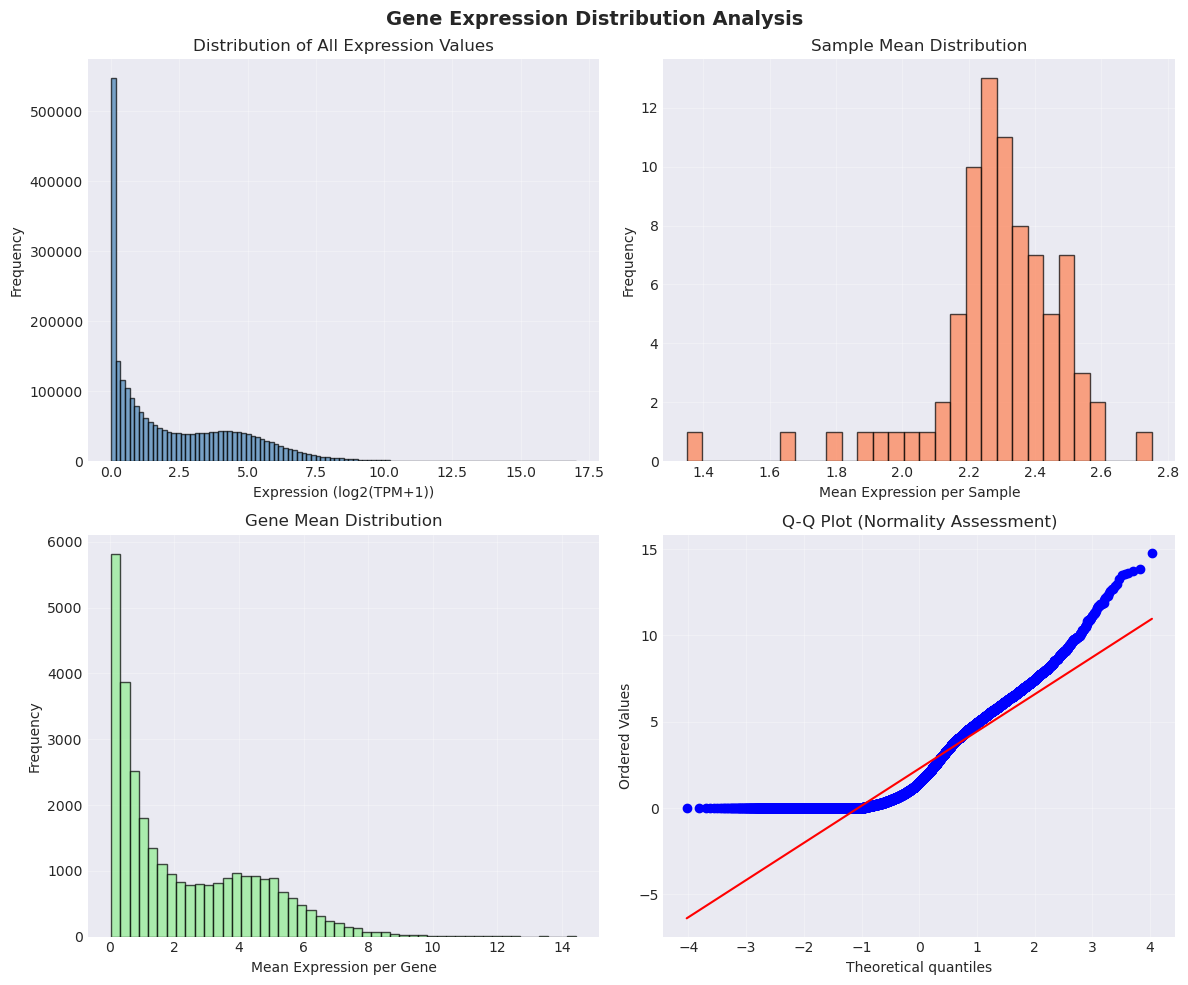


✓ Distribution plot saved to figures/01_expression_distribution.png


In [8]:
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print()

# Sample-level statistics
print("Sample-level statistics:")
sample_means = expr.mean(axis=1)
sample_sds = expr.std(axis=1)
print(f"  Expression mean (per sample): {sample_means.mean():.2f} ± {sample_means.std():.2f}")
print(f"  Expression SD (per sample): {sample_sds.mean():.2f} ± {sample_sds.std():.2f}")
print()

# Gene-level statistics
print("Gene-level statistics:")
gene_means = expr.mean(axis=0)
gene_sds = expr.std(axis=0)
print(f"  Top 5 highest-expressed genes:")
top_genes = gene_means.nlargest(5)
for gene, value in top_genes.items():
    print(f"    {gene}: {value:.2f}")
print()

# Overall distribution
print("Overall expression distribution:")
print(f"  Mean: {expr.mean().mean():.2f}")
print(f"  Median: {expr.median().median():.2f}")
print(f"  Min: {expr.min().min():.2f}")
print(f"  Max: {expr.max().max():.2f}")
print(f"  Skewness: {skew(expr.values.flatten()):.2f}")
print(f"  Kurtosis: {kurtosis(expr.values.flatten()):.2f}")

# Plot distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Gene Expression Distribution Analysis', fontsize=14, fontweight='bold')

# Histogram of all values
axes[0, 0].hist(expr.values.flatten(), bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Expression (log2(TPM+1))')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of All Expression Values')
axes[0, 0].grid(alpha=0.3)

# Sample means
axes[0, 1].hist(sample_means, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Mean Expression per Sample')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sample Mean Distribution')
axes[0, 1].grid(alpha=0.3)

# Gene means
axes[1, 0].hist(gene_means, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Mean Expression per Gene')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Gene Mean Distribution')
axes[1, 0].grid(alpha=0.3)

# Q-Q plot
from scipy.stats import probplot
probplot(expr.values.flatten()[::100], dist="norm", plot=axes[1, 1])  # Sample every 100th value
axes[1, 1].set_title('Q-Q Plot (Normality Assessment)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_expression_distribution.png", dpi=300, bbox_inches='tight')
display(fig)
plt.close()

print("\n✓ Distribution plot saved to figures/01_expression_distribution.png")

## Section 6: Feature Selection
Select most informative genes based on statistical significance and variance.

In [9]:
print("FEATURE SELECTION (Top genes by variance)")
print("=" * 60)

# ------------------------------------------------------------
# 1. Unsupervised feature selection: Top variable genes
# ------------------------------------------------------------

N_TOP_GENES = 500

# Clean expression matrix
expr_clean = expr.replace([np.inf, -np.inf], np.nan)
expr_clean = expr_clean.fillna(expr_clean.median())

# Calculate gene variances
gene_variances = expr_clean.var(axis=0).sort_values(ascending=False)
top_genes = gene_variances.head(N_TOP_GENES).index.tolist()

# Selected expression matrix
expr_top = expr_clean[top_genes].copy()

print(f"Selected top {len(top_genes)} genes by variance")
print(f"Variance range: [{gene_variances[top_genes].min():.2f}, {gene_variances[top_genes].max():.2f}]")
print()


# ------------------------------------------------------------
# 2. Supervised feature selection: PAM50 subtype discrimination
# ------------------------------------------------------------

top_supervised = None
expr_supervised = None
feature_scores = None
pam50_unique = None

if pam50 is not None and subtype_col:
    print("SUPERVISED FEATURE SELECTION (using PAM50 subtypes)")
    print("-" * 60)

    # Remove duplicate sample IDs from PAM50 index
    pam50_unique = pam50.copy()
    n_duplicates = pam50_unique.index.duplicated().sum()

    if n_duplicates > 0:
        print(f"⚠️ Duplicate PAM50 sample IDs found: {n_duplicates}")
        print("⚠️ Keeping the first occurrence for each duplicated sample ID.")

    pam50_unique = pam50_unique[~pam50_unique.index.duplicated(keep="first")]

    # Find common sample IDs
    common_samples = expr_clean.index.intersection(pam50_unique.index)

    print(f"Expression samples: {expr_clean.shape[0]}")
    print(f"PAM50 samples: {pam50.shape[0]}")
    print(f"PAM50 unique samples: {pam50_unique.shape[0]}")
    print(f"Common samples: {len(common_samples)}")

    if len(common_samples) < 10:
        print("⚠️ Too few common samples between expr and PAM50.")
        print("⚠️ Check sample ID formatting/index alignment.")
        print("⚠️ Supervised feature selection skipped.")

    else:
        # Build one aligned dataframe
        supervised_df = expr_clean.loc[common_samples].copy()

        # Add subtype labels safely
        supervised_df["PAM50_subtype"] = pam50_unique.loc[
            common_samples, subtype_col
        ]

        # Remove samples without PAM50 subtype
        supervised_df = supervised_df.dropna(subset=["PAM50_subtype"])

        # Separate X and y
        X_supervised = supervised_df.drop(columns=["PAM50_subtype"])
        y_labels = supervised_df["PAM50_subtype"]

        print(f"Valid labeled samples: {X_supervised.shape[0]}")
        print(f"Number of genes used: {X_supervised.shape[1]}")

        if X_supervised.shape[0] < 10:
            print("⚠️ Too few valid labeled samples after removing missing PAM50 labels.")
            print("⚠️ Supervised feature selection skipped.")

        elif y_labels.nunique() < 2:
            print("⚠️ PAM50 labels contain fewer than 2 classes.")
            print("⚠️ Supervised feature selection skipped.")

        else:
            # Encode PAM50 subtype labels
            le = LabelEncoder()
            y_subtype = le.fit_transform(y_labels)

            print("PAM50 classes:")
            for class_id, class_name in enumerate(le.classes_):
                print(f"  {class_id}: {class_name}")

            # SelectKBest with ANOVA F-test
            k_features = min(100, X_supervised.shape[1])

            selector = SelectKBest(
                score_func=f_classif,
                k=k_features
            )

            selector.fit(X_supervised, y_subtype)

            # Store feature scores
            feature_scores = pd.DataFrame({
                "gene": X_supervised.columns,
                "f_score": selector.scores_,
                "p_value": selector.pvalues_
            }).sort_values("f_score", ascending=False)

            print()
            print("Top 10 discriminative genes by F-score:")
            print(feature_scores.head(10).to_string(index=False))

            # Select top supervised genes
            top_supervised = feature_scores.head(k_features)["gene"].tolist()
            expr_supervised = expr_clean[top_supervised].copy()

            print(f"\n✓ Selected {len(top_supervised)} genes for subtype discrimination")

else:
    print("⚠️ PAM50 data not available - supervised feature selection skipped")


# ------------------------------------------------------------
# 3. Summary
# ------------------------------------------------------------

print()
print("FEATURE SELECTION SUMMARY")
print("=" * 60)

print(f"✓ Unsupervised: {len(top_genes)} most variable genes")

if top_supervised is not None:
    print(f"✓ Supervised: {len(top_supervised)} subtype-discriminative genes")
else:
    print("⚠️ Supervised: skipped")

print("✓ Using unsupervised selection for downstream analyses")

FEATURE SELECTION (Top genes by variance)
Selected top 500 genes by variance
Variance range: [3.49, 19.44]

SUPERVISED FEATURE SELECTION (using PAM50 subtypes)
------------------------------------------------------------
⚠️ Duplicate PAM50 sample IDs found: 62
⚠️ Keeping the first occurrence for each duplicated sample ID.
Expression samples: 82
PAM50 samples: 131
PAM50 unique samples: 69
Common samples: 69
Valid labeled samples: 82
Number of genes used: 30447
PAM50 classes:
  0: Basal
  1: Her2
  2: LumA
  3: LumB
  4: Normal
  5: Unknown

Top 10 discriminative genes by F-score:
              gene     f_score      p_value
ENSG00000118733.17 1000.495012 8.139217e-68
 ENSG00000135222.6  114.481189 6.439227e-34
 ENSG00000154478.4   47.302731 5.712583e-22
 ENSG00000253152.1   41.437404 2.300257e-20
ENSG00000124557.12   40.203470 5.249790e-20
 ENSG00000283117.1   38.758983 1.411663e-19
 ENSG00000167531.6   36.577186 6.613424e-19
 ENSG00000224927.2   34.934858 2.206839e-18
ENSG00000163618.18

## Section 7: Correlation Analysis
Compute gene-gene correlation matrices and identify co-expressed gene clusters.

CORRELATION ANALYSIS
Computing Pearson correlation...
Computing Spearman correlation...
Computing Kendall correlation...

Correlation matrix summary:
  Pearson - Mean: 0.104
  Spearman - Mean: 0.127
  Kendall - Mean: 0.091

Top 10 most correlated gene pairs (Pearson):
             Gene1              Gene2  Correlation
ENSG00000187288.12  ENSG00000184811.4     0.991327
 ENSG00000235687.9  ENSG00000234918.1     0.987908
ENSG00000187288.12 ENSG00000167588.13     0.982441
ENSG00000181092.10 ENSG00000196616.14     0.982383
ENSG00000167588.13  ENSG00000184811.4     0.982264
 ENSG00000184811.4 ENSG00000176194.18     0.978660
 ENSG00000287148.1 ENSG00000165269.13     0.978514
ENSG00000181092.10 ENSG00000166819.12     0.976575
ENSG00000181092.10 ENSG00000187288.12     0.976060
ENSG00000181092.10  ENSG00000184811.4     0.975536


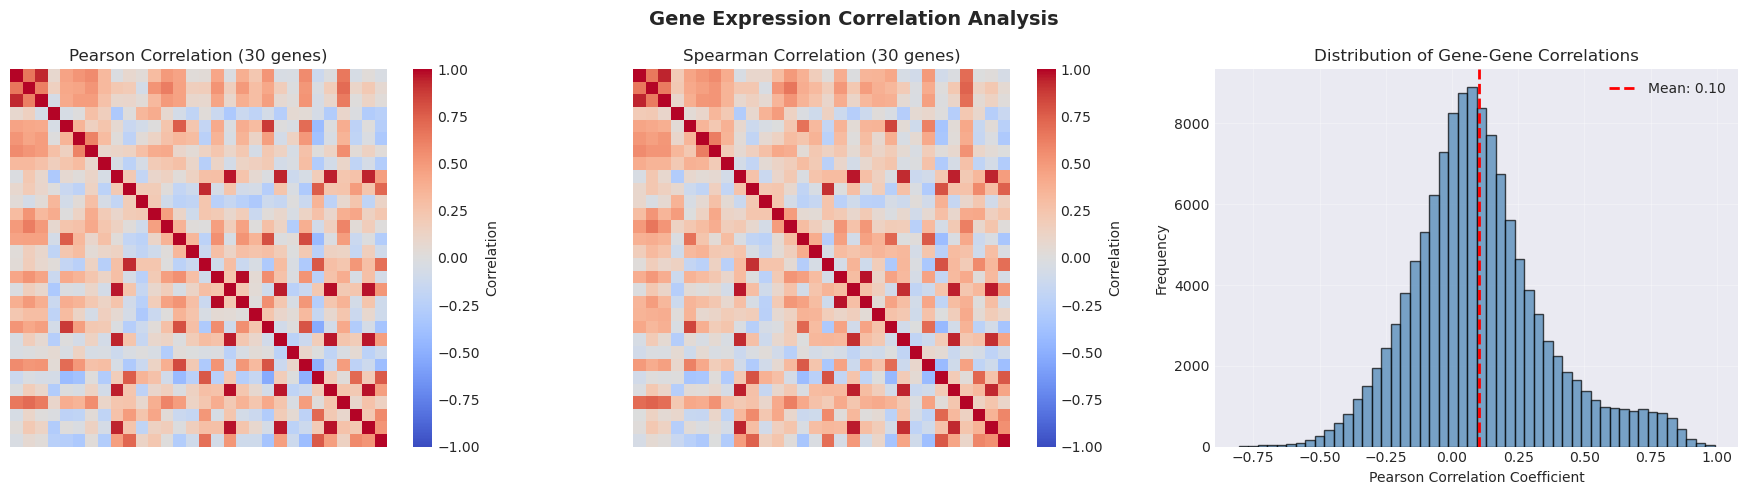


✓ Correlation matrices and top correlated gene pairs saved


In [10]:
print("CORRELATION ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Prepare expression data
# ------------------------------------------------------------

expr_corr = expr_top.copy()

# Clean possible NaN / inf values
expr_corr = expr_corr.replace([np.inf, -np.inf], np.nan)
expr_corr = expr_corr.fillna(expr_corr.median())

# Remove index/column axis names to prevent reset_index conflicts
expr_corr.index.name = None
expr_corr.columns.name = None


# ------------------------------------------------------------
# 2. Compute correlations
# ------------------------------------------------------------

print("Computing Pearson correlation...")
corr_pearson = expr_corr.corr(method="pearson")

print("Computing Spearman correlation...")
corr_spearman = expr_corr.corr(method="spearman")

print("Computing Kendall correlation...")
corr_kendall = expr_corr.corr(method="kendall")

# Remove axis names from correlation matrices
corr_pearson.index.name = None
corr_pearson.columns.name = None
corr_spearman.index.name = None
corr_spearman.columns.name = None
corr_kendall.index.name = None
corr_kendall.columns.name = None


# ------------------------------------------------------------
# 3. Summary statistics
# ------------------------------------------------------------

pearson_upper = corr_pearson.values[np.triu_indices_from(corr_pearson.values, k=1)]
spearman_upper = corr_spearman.values[np.triu_indices_from(corr_spearman.values, k=1)]
kendall_upper = corr_kendall.values[np.triu_indices_from(corr_kendall.values, k=1)]

print()
print("Correlation matrix summary:")
print(f"  Pearson - Mean: {np.nanmean(pearson_upper):.3f}")
print(f"  Spearman - Mean: {np.nanmean(spearman_upper):.3f}")
print(f"  Kendall - Mean: {np.nanmean(kendall_upper):.3f}")


# ------------------------------------------------------------
# 4. Top correlated gene pairs
# ------------------------------------------------------------

print()
print("Top 10 most correlated gene pairs (Pearson):")

mask = np.triu(np.ones(corr_pearson.shape, dtype=bool), k=1)

corr_pairs = (
    corr_pearson
    .where(mask)
    .stack()
    .rename("Correlation")
    .reset_index()
)

corr_pairs.columns = ["Gene1", "Gene2", "Correlation"]
corr_pairs = corr_pairs.sort_values("Correlation", ascending=False)

print(corr_pairs.head(10).to_string(index=False))


# ------------------------------------------------------------
# 5. Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Gene Expression Correlation Analysis", fontsize=14, fontweight="bold")

n_heatmap = min(30, expr_corr.shape[1])
heatmap_genes = expr_corr.var().nlargest(n_heatmap).index

sns.heatmap(
    corr_pearson.loc[heatmap_genes, heatmap_genes],
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0],
    cbar_kws={"label": "Correlation"},
    xticklabels=False,
    yticklabels=False
)
axes[0].set_title(f"Pearson Correlation ({n_heatmap} genes)")

sns.heatmap(
    corr_spearman.loc[heatmap_genes, heatmap_genes],
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1],
    cbar_kws={"label": "Correlation"},
    xticklabels=False,
    yticklabels=False
)
axes[1].set_title(f"Spearman Correlation ({n_heatmap} genes)")

corr_upper = pearson_upper[~np.isnan(pearson_upper)]

axes[2].hist(
    corr_upper,
    bins=50,
    alpha=0.7,
    color="steelblue",
    edgecolor="black"
)
axes[2].set_xlabel("Pearson Correlation Coefficient")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of Gene-Gene Correlations")
axes[2].axvline(
    corr_upper.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {corr_upper.mean():.2f}"
)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(FIGURES_DIR / "02_correlation_analysis.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close()


# ------------------------------------------------------------
# 6. Save outputs
# ------------------------------------------------------------

corr_pearson.to_csv(TABLES_DIR / "correlation_pearson.csv")
corr_spearman.to_csv(TABLES_DIR / "correlation_spearman.csv")
corr_kendall.to_csv(TABLES_DIR / "correlation_kendall.csv")
corr_pairs.to_csv(TABLES_DIR / "top_correlated_gene_pairs_pearson.csv", index=False)

print("\n✓ Correlation matrices and top correlated gene pairs saved")

## Section 8: Principal Component Analysis (PCA)
Reduce dimensionality and visualize sample relationships in principal component space.

PRINCIPAL COMPONENT ANALYSIS (PCA)
Total samples: 82
Total genes (features): 500
PCA components: 50

Variance explained:
  PC1: 17.7%
  PC2: 14.0%
  PC1+PC2: 31.7%
  Top 10 PCs: 65.1%
  Components for 90% variance: 41

PCA subtype annotation:
  Samples with PAM50 label: 82
  Samples without PAM50 label: 0


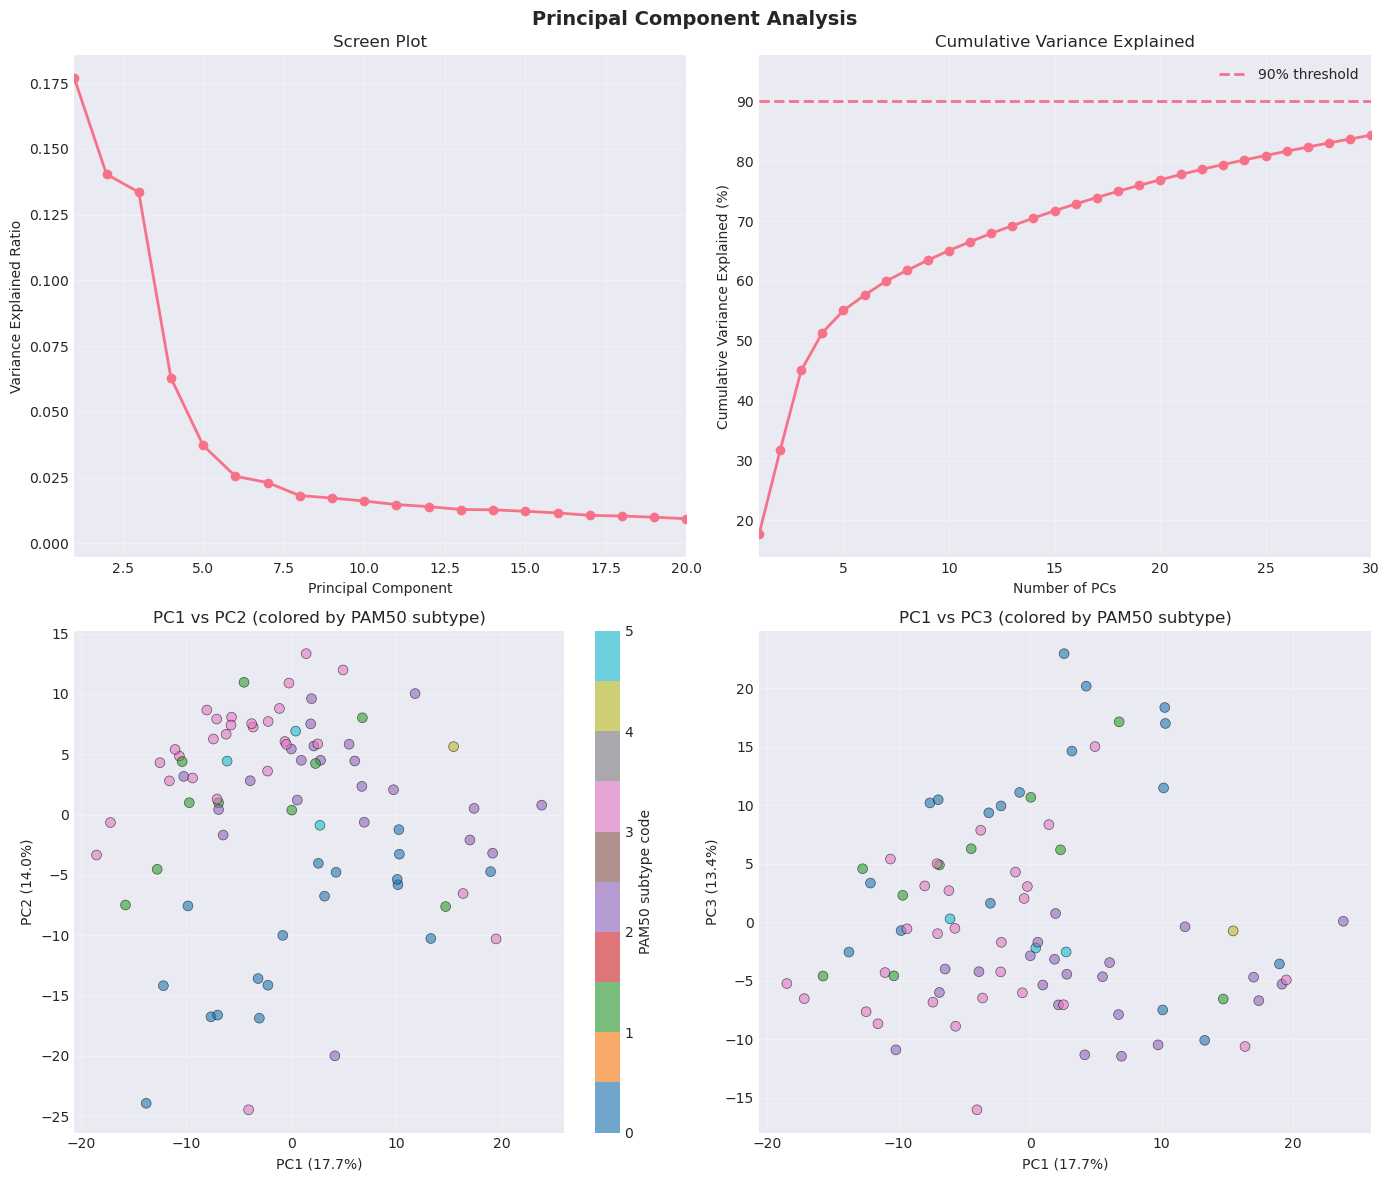


✓ PCA analysis complete


In [11]:
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 60)

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

expr_pca = expr_top.copy()

# Clean NaN / inf
expr_pca = expr_pca.replace([np.inf, -np.inf], np.nan)
expr_pca = expr_pca.fillna(expr_pca.median())

# Remove axis names to avoid downstream conflicts
expr_pca.index.name = None
expr_pca.columns.name = None

# ------------------------------------------------------------
# 2. Standardize data
# ------------------------------------------------------------

scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_pca)

# ------------------------------------------------------------
# 3. Fit PCA
# ------------------------------------------------------------

n_components = min(50, expr_scaled.shape[0], expr_scaled.shape[1])

pca = PCA(n_components=n_components)
pca_transformed = pca.fit_transform(expr_scaled)

cumsum_var = np.cumsum(pca.explained_variance_ratio_)

print(f"Total samples: {pca_transformed.shape[0]}")
print(f"Total genes (features): {expr_pca.shape[1]}")
print(f"PCA components: {pca.n_components_}")
print()
print("Variance explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")

if pca.n_components_ >= 2:
    print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
    print(f"  PC1+PC2: {cumsum_var[1]*100:.1f}%")

if pca.n_components_ >= 10:
    print(f"  Top 10 PCs: {cumsum_var[9]*100:.1f}%")
else:
    print(f"  All PCs: {cumsum_var[-1]*100:.1f}%")

n_pc_90 = np.argmax(cumsum_var >= 0.90) + 1
print(f"  Components for 90% variance: {n_pc_90}")

# ------------------------------------------------------------
# 4. PCA dataframe
# ------------------------------------------------------------

pca_df = pd.DataFrame(
    pca_transformed,
    index=expr_pca.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# ------------------------------------------------------------
# 5. Prepare PAM50 labels safely
# ------------------------------------------------------------

pca_subtypes = None

if pam50 is not None and subtype_col:
    pam50_unique = pam50.copy()
    pam50_unique = pam50_unique[~pam50_unique.index.duplicated(keep="first")]

    pca_subtypes = pam50_unique[subtype_col].reindex(pca_df.index)

    valid_color_mask = pca_subtypes.notna()

    print()
    print("PCA subtype annotation:")
    print(f"  Samples with PAM50 label: {valid_color_mask.sum()}")
    print(f"  Samples without PAM50 label: {(~valid_color_mask).sum()}")

# ------------------------------------------------------------
# 6. Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Principal Component Analysis", fontsize=14, fontweight="bold")

# Scree plot
axes[0, 0].plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    "o-",
    linewidth=2,
    markersize=6
)
axes[0, 0].set_xlabel("Principal Component")
axes[0, 0].set_ylabel("Variance Explained Ratio")
axes[0, 0].set_title("Screen Plot")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim(1, min(20, pca.n_components_))

# Cumulative variance
axes[0, 1].plot(
    np.arange(1, len(cumsum_var) + 1),
    cumsum_var * 100,
    "o-",
    linewidth=2,
    markersize=6
)
axes[0, 1].axhline(90, linestyle="--", linewidth=2, label="90% threshold")
axes[0, 1].set_xlabel("Number of PCs")
axes[0, 1].set_ylabel("Cumulative Variance Explained (%)")
axes[0, 1].set_title("Cumulative Variance Explained")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_xlim(1, min(30, pca.n_components_))

# PC1 vs PC2
if pca.n_components_ >= 2:
    if pca_subtypes is not None:
        plot_df = pca_df.copy()
        plot_df["PAM50_subtype"] = pca_subtypes
        plot_df = plot_df.dropna(subset=["PAM50_subtype"])

        color_codes = pd.Categorical(plot_df["PAM50_subtype"]).codes

        scatter = axes[1, 0].scatter(
            plot_df["PC1"],
            plot_df["PC2"],
            c=color_codes,
            cmap="tab10",
            s=50,
            alpha=0.6,
            edgecolors="black",
            linewidth=0.5
        )
        axes[1, 0].set_title("PC1 vs PC2 (colored by PAM50 subtype)")
        cbar = plt.colorbar(scatter, ax=axes[1, 0])
        cbar.set_label("PAM50 subtype code")
    else:
        axes[1, 0].scatter(
            pca_df["PC1"],
            pca_df["PC2"],
            s=50,
            alpha=0.6,
            edgecolors="black",
            linewidth=0.5
        )
        axes[1, 0].set_title("PC1 vs PC2")

    axes[1, 0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    axes[1, 0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    axes[1, 0].grid(alpha=0.3)
else:
    axes[1, 0].axis("off")

# PC1 vs PC3
if pca.n_components_ >= 3:
    if pca_subtypes is not None:
        plot_df = pca_df.copy()
        plot_df["PAM50_subtype"] = pca_subtypes
        plot_df = plot_df.dropna(subset=["PAM50_subtype"])

        color_codes = pd.Categorical(plot_df["PAM50_subtype"]).codes

        scatter = axes[1, 1].scatter(
            plot_df["PC1"],
            plot_df["PC3"],
            c=color_codes,
            cmap="tab10",
            s=50,
            alpha=0.6,
            edgecolors="black",
            linewidth=0.5
        )
        axes[1, 1].set_title("PC1 vs PC3 (colored by PAM50 subtype)")
    else:
        axes[1, 1].scatter(
            pca_df["PC1"],
            pca_df["PC3"],
            s=50,
            alpha=0.6,
            edgecolors="black",
            linewidth=0.5
        )
        axes[1, 1].set_title("PC1 vs PC3")

    axes[1, 1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    axes[1, 1].set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
    axes[1, 1].grid(alpha=0.3)
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_pca_analysis.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close()

# ------------------------------------------------------------
# 7. Save PCA results
# ------------------------------------------------------------

pca_df.to_csv(TABLES_DIR / "pca_scores.csv")

pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=expr_pca.columns
)

pca_loadings.to_csv(TABLES_DIR / "pca_loadings.csv")

if pca_subtypes is not None:
    pca_df_with_subtype = pca_df.copy()
    pca_df_with_subtype["PAM50_subtype"] = pca_subtypes
    pca_df_with_subtype.to_csv(TABLES_DIR / "pca_scores_with_pam50.csv")

print("\n✓ PCA analysis complete")

## Section 9: Clustering Analysis
Identify molecular subtypes using multiple clustering algorithms (KMeans, Hierarchical, DBSCAN, Gaussian Mixture).

CLUSTERING ANALYSIS
Optimal number of clusters (by Silhouette score): 3

Fitting clustering algorithms...
DBSCAN found 0 clusters (noise points: 82)

Clustering Quality Metrics:
  KMeans Silhouette: 0.268
  Hierarchical Silhouette: 0.267
  GMM Silhouette: 0.268

KMeans cluster distribution:
0    16
1    49
2    17
Name: count, dtype: int64


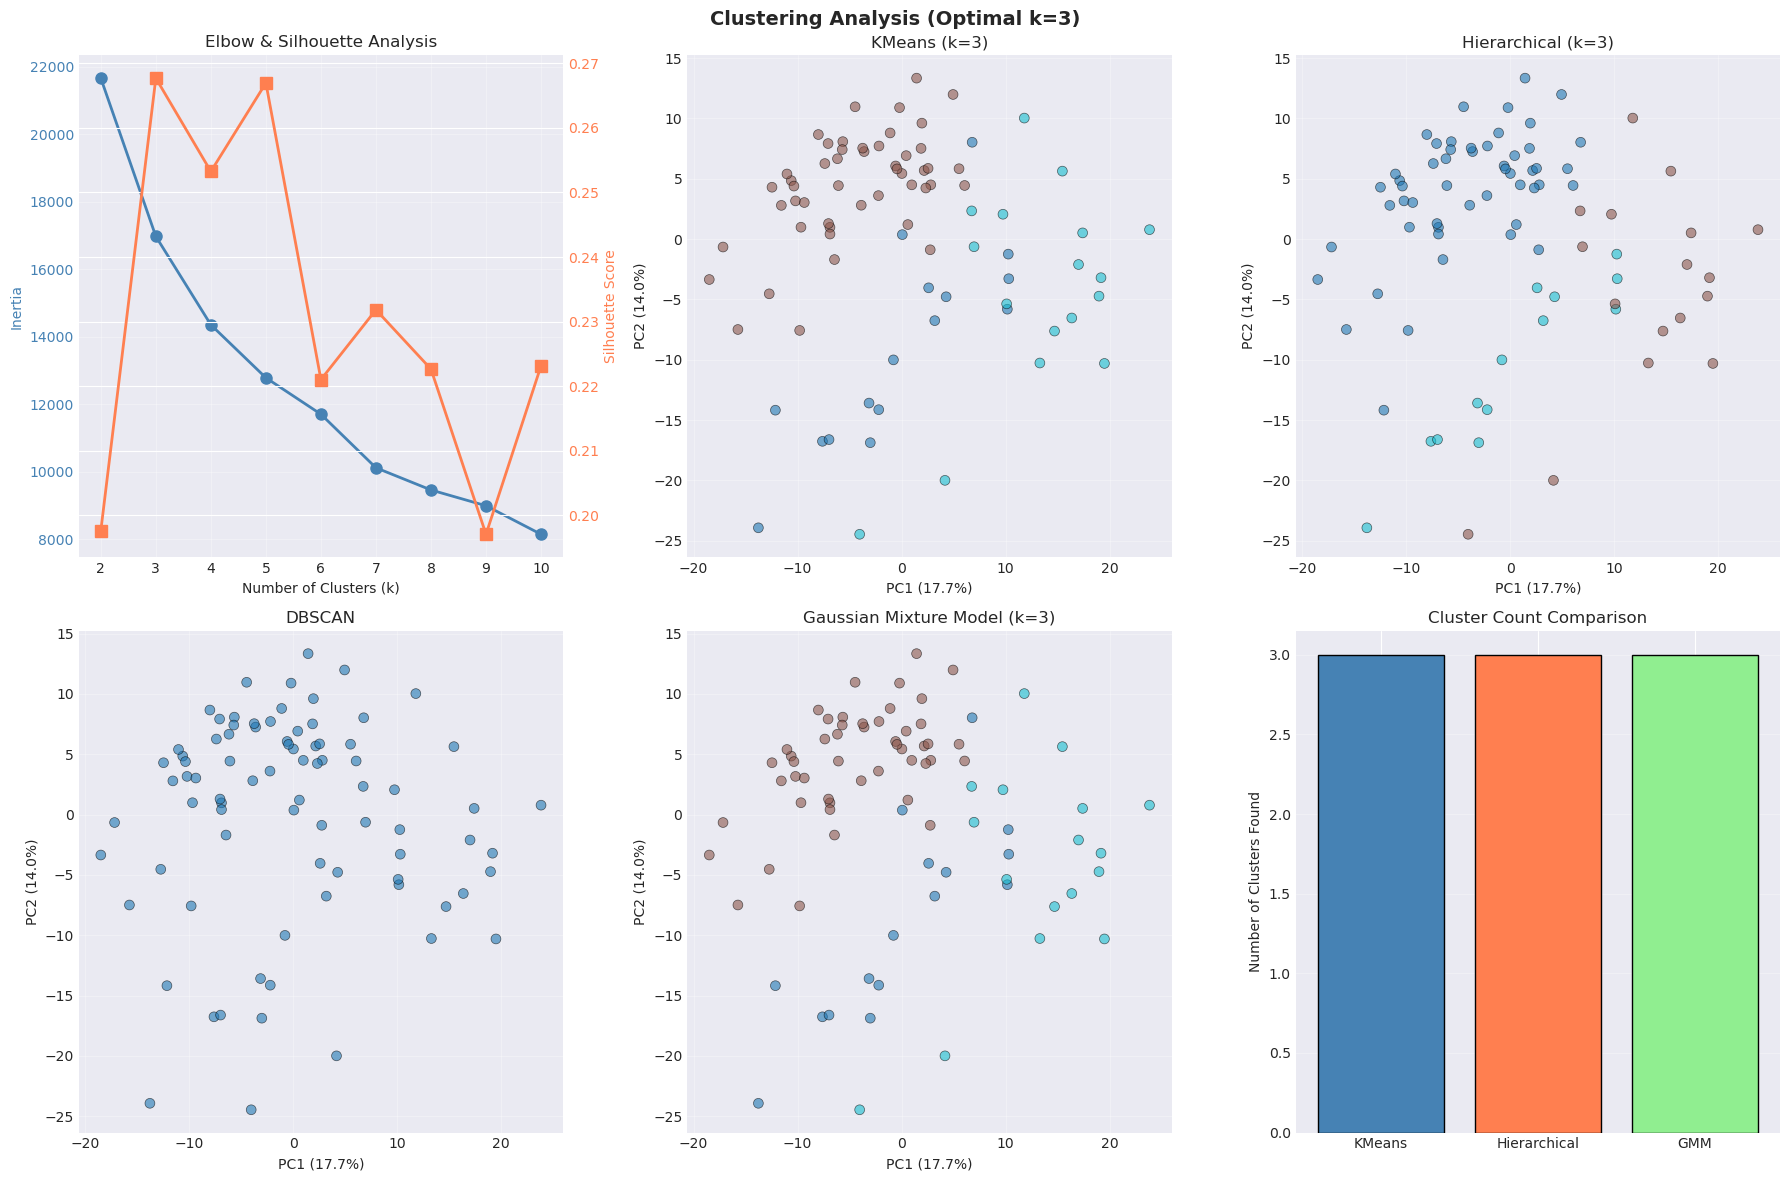


✓ Clustering analysis complete


In [12]:
print("CLUSTERING ANALYSIS")
print("=" * 60)

# Use PCA data for clustering (first 10 PCs for visualization + stability)
X_clust = pca_transformed[:, :10]

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clust, labels))

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (by Silhouette score): {optimal_k}")
print()

# Fit clustering algorithms
print("Fitting clustering algorithms...")

# KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clust)

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hierarchical.fit_predict(X_clust)

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_clust)
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN found {n_dbscan_clusters} clusters (noise points: {list(dbscan_labels).count(-1)})")

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_clust)

# Clustering quality metrics
print()
print("Clustering Quality Metrics:")
print(f"  KMeans Silhouette: {silhouette_score(X_clust, kmeans_labels):.3f}")
print(f"  Hierarchical Silhouette: {silhouette_score(X_clust, hier_labels):.3f}")
if n_dbscan_clusters > 1:
    print(f"  DBSCAN Silhouette: {silhouette_score(X_clust, dbscan_labels):.3f}")
print(f"  GMM Silhouette: {silhouette_score(X_clust, gmm_labels):.3f}")

# Cluster distributions
print()
print(f"KMeans cluster distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Clustering Analysis (Optimal k={optimal_k})', fontsize=14, fontweight='bold')

# Elbow + Silhouette
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8, label='Inertia')
ax1_twin.plot(k_range, silhouette_scores, 's-', color='coral', linewidth=2, markersize=8, label='Silhouette')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='steelblue')
ax1_twin.set_ylabel('Silhouette Score', color='coral')
ax1.set_title('Elbow & Silhouette Analysis')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1_twin.tick_params(axis='y', labelcolor='coral')

# KMeans
scatter = axes[0, 1].scatter(pca_df['PC1'], pca_df['PC2'], c=kmeans_labels, 
                             cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0, 1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0, 1].set_title(f'KMeans (k={optimal_k})')
axes[0, 1].grid(alpha=0.3)

# Hierarchical
scatter = axes[0, 2].scatter(pca_df['PC1'], pca_df['PC2'], c=hier_labels, 
                             cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0, 2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0, 2].set_title(f'Hierarchical (k={optimal_k})')
axes[0, 2].grid(alpha=0.3)

# DBSCAN
scatter = axes[1, 0].scatter(pca_df['PC1'], pca_df['PC2'], c=dbscan_labels, 
                             cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1, 0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1, 0].set_title(f'DBSCAN')
axes[1, 0].grid(alpha=0.3)

# GMM
scatter = axes[1, 1].scatter(pca_df['PC1'], pca_df['PC2'], c=gmm_labels, 
                             cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1, 1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1, 1].set_title(f'Gaussian Mixture Model (k={optimal_k})')
axes[1, 1].grid(alpha=0.3)

# Cluster size comparison
cluster_methods = ['KMeans', 'Hierarchical', 'GMM']
all_labels = [kmeans_labels, hier_labels, gmm_labels]
cluster_sizes = [len(set(l)) for l in all_labels]
axes[1, 2].bar(cluster_methods, cluster_sizes, color=['steelblue', 'coral', 'lightgreen'], edgecolor='black')
axes[1, 2].set_ylabel('Number of Clusters Found')
axes[1, 2].set_title('Cluster Count Comparison')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_clustering_analysis.png", dpi=300, bbox_inches='tight')
display(fig)
plt.close()

# Save clustering results
clustering_df = pd.DataFrame({
    'Sample': expr.index,
    'KMeans': kmeans_labels,
    'Hierarchical': hier_labels,
    'DBSCAN': dbscan_labels,
    'GMM': gmm_labels
})
clustering_df.to_csv(TABLES_DIR / "clustering_assignments.csv", index=False)

print("\n✓ Clustering analysis complete")

## Section 10: Machine Learning Classification
Predict PAM50 subtypes using multiple classifiers (Logistic Regression, Random Forest, SVM, k-NN, XGBoost).

MACHINE LEARNING CLASSIFICATION
Predicting PAM50 subtypes from gene expression

⚠️ Duplicate PAM50 sample IDs found: 62
⚠️ Keeping first occurrence for each duplicated sample ID.
Expression samples: 82
PAM50 samples: 131
PAM50 unique samples: 69
Common samples: 69
Valid labeled samples: 82
Genes/features: 500

⚠️ Removing classes with fewer than 2 samples:
Normal    1

Class distribution:
LumB       28
LumA       22
Basal      18
Her2       10
Unknown     3

Training set: 64 samples
Test set: 17 samples
Number of classes: 5

Training Logistic Regression...
  Accuracy: 0.824, F1: 0.807
Training Random Forest...
  Accuracy: 0.765, F1: 0.701
Training SVM (RBF)...
  Accuracy: 0.765, F1: 0.694
Training k-NN (k=5)...
  Accuracy: 0.588, F1: 0.543
Training XGBoost...
  Accuracy: 0.824, F1: 0.811

Classification Results:
         Classifier  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.823529   0.807843 0.823529  0.807130
            XGBoost  0.823529   0.823529 0.823529  0.811

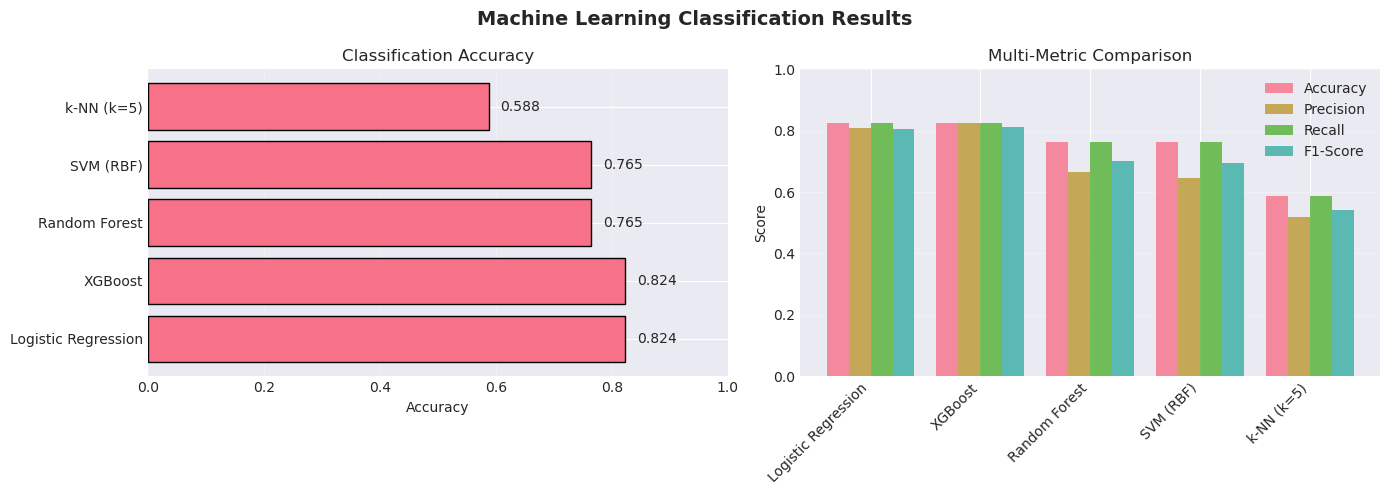


Best Classifier: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         4
        Her2       0.67      1.00      0.80         2
        LumA       0.60      0.75      0.67         4
        LumB       1.00      0.83      0.91         6
     Unknown       0.00      0.00      0.00         1

    accuracy                           0.82        17
   macro avg       0.65      0.72      0.68        17
weighted avg       0.81      0.82      0.81        17


✓ ML Classification complete


In [13]:
if pam50 is not None and subtype_col:
    print("MACHINE LEARNING CLASSIFICATION")
    print("=" * 60)
    print("Predicting PAM50 subtypes from gene expression")
    print()

    # ------------------------------------------------------------
    # 1. Prepare aligned expression + PAM50 data
    # ------------------------------------------------------------

    expr_ml = expr_top.copy()
    expr_ml = expr_ml.replace([np.inf, -np.inf], np.nan)
    expr_ml = expr_ml.fillna(expr_ml.median())

    # Remove duplicate PAM50 sample IDs
    pam50_unique = pam50.copy()
    n_duplicates = pam50_unique.index.duplicated().sum()

    if n_duplicates > 0:
        print(f"⚠️ Duplicate PAM50 sample IDs found: {n_duplicates}")
        print("⚠️ Keeping first occurrence for each duplicated sample ID.")

    pam50_unique = pam50_unique[~pam50_unique.index.duplicated(keep="first")]

    # Keep only common samples
    common_samples = expr_ml.index.intersection(pam50_unique.index)

    print(f"Expression samples: {expr_ml.shape[0]}")
    print(f"PAM50 samples: {pam50.shape[0]}")
    print(f"PAM50 unique samples: {pam50_unique.shape[0]}")
    print(f"Common samples: {len(common_samples)}")

    if len(common_samples) < 10:
        print("⚠️ Too few common samples between expression and PAM50.")
        print("⚠️ ML classification skipped.")

    else:
        ml_df = expr_ml.loc[common_samples].copy()
        ml_df["PAM50_subtype"] = pam50_unique.loc[common_samples, subtype_col]

        # Remove missing labels
        ml_df = ml_df.dropna(subset=["PAM50_subtype"])

        X = ml_df.drop(columns=["PAM50_subtype"]).values
        y = ml_df["PAM50_subtype"].values

        print(f"Valid labeled samples: {X.shape[0]}")
        print(f"Genes/features: {X.shape[1]}")

        # Remove classes with fewer than 2 samples
        class_counts = pd.Series(y).value_counts()
        valid_classes = class_counts[class_counts >= 2].index

        if len(valid_classes) < len(class_counts):
            removed_classes = class_counts[class_counts < 2]
            print()
            print("⚠️ Removing classes with fewer than 2 samples:")
            print(removed_classes.to_string())

        valid_mask = pd.Series(y).isin(valid_classes).values
        X = X[valid_mask]
        y = y[valid_mask]

        class_counts = pd.Series(y).value_counts()

        print()
        print("Class distribution:")
        print(class_counts.to_string())

        if X.shape[0] < 10:
            print("⚠️ Too few samples after filtering rare classes.")
            print("⚠️ ML classification skipped.")

        elif len(class_counts) < 2:
            print("⚠️ Fewer than 2 valid PAM50 classes.")
            print("⚠️ ML classification skipped.")

        else:
            # ------------------------------------------------------------
            # 2. Encode labels and standardize features
            # ------------------------------------------------------------

            le_target = LabelEncoder()
            y_encoded = le_target.fit_transform(y)

            X_scaled = StandardScaler().fit_transform(X)

            # Adaptive test size
            min_class_count = class_counts.min()
            n_classes = len(class_counts)

            test_size = 0.2

            # Ensure test set can contain at least one sample from each class
            if int(np.ceil(X.shape[0] * test_size)) < n_classes:
                test_size = n_classes / X.shape[0]

            # Ensure train set also keeps enough samples
            if min_class_count < 2:
                stratify_arg = None
                print("⚠️ Stratification disabled because at least one class has <2 samples.")
            else:
                stratify_arg = y_encoded

            X_train, X_test, y_train, y_test = train_test_split(
                X_scaled,
                y_encoded,
                test_size=test_size,
                random_state=42,
                stratify=stratify_arg
            )

            print()
            print(f"Training set: {X_train.shape[0]} samples")
            print(f"Test set: {X_test.shape[0]} samples")
            print(f"Number of classes: {len(np.unique(y_encoded))}")
            print()

            # ------------------------------------------------------------
            # 3. Define classifiers
            # ------------------------------------------------------------

            classifiers = {
                "Logistic Regression": LogisticRegression(
                    max_iter=1000,
                    random_state=42
                ),
                "Random Forest": RandomForestClassifier(
                    n_estimators=100,
                    random_state=42,
                    n_jobs=-1
                ),
                "SVM (RBF)": SVC(
                    kernel="rbf",
                    probability=True,
                    random_state=42
                ),
                "k-NN (k=5)": KNeighborsClassifier(
                    n_neighbors=min(5, X_train.shape[0])
                ),
            }

            if XGBOOST_AVAILABLE:
                classifiers["XGBoost"] = xgb.XGBClassifier(
                    n_estimators=100,
                    random_state=42,
                    eval_metric="mlogloss"
                )

            # ------------------------------------------------------------
            # 4. Train and evaluate classifiers
            # ------------------------------------------------------------

            results = []

            for name, clf in classifiers.items():
                print(f"Training {name}...")

                try:
                    clf.fit(X_train, y_train)
                    y_pred = clf.predict(X_test)

                    accuracy = accuracy_score(y_test, y_pred)
                    precision = precision_score(
                        y_test, y_pred,
                        average="weighted",
                        zero_division=0
                    )
                    recall = recall_score(
                        y_test, y_pred,
                        average="weighted",
                        zero_division=0
                    )
                    f1 = f1_score(
                        y_test, y_pred,
                        average="weighted",
                        zero_division=0
                    )

                    results.append({
                        "Classifier": name,
                        "Accuracy": accuracy,
                        "Precision": precision,
                        "Recall": recall,
                        "F1-Score": f1
                    })

                    print(f"  Accuracy: {accuracy:.3f}, F1: {f1:.3f}")

                except Exception as e:
                    print(f"  ⚠️ {name} failed: {e}")

            results_df = pd.DataFrame(results)

            if results_df.empty:
                print("⚠️ No classifier completed successfully.")

            else:
                results_df = results_df.sort_values("Accuracy", ascending=False)

                print()
                print("Classification Results:")
                print(results_df.to_string(index=False))

                # ------------------------------------------------------------
                # 5. Visualization
                # ------------------------------------------------------------

                fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                fig.suptitle(
                    "Machine Learning Classification Results",
                    fontsize=14,
                    fontweight="bold"
                )

                axes[0].barh(
                    results_df["Classifier"],
                    results_df["Accuracy"],
                    edgecolor="black"
                )
                axes[0].set_xlabel("Accuracy")
                axes[0].set_title("Classification Accuracy")
                axes[0].set_xlim(0, 1)

                for i, v in enumerate(results_df["Accuracy"]):
                    axes[0].text(v + 0.02, i, f"{v:.3f}", va="center")

                axes[0].grid(alpha=0.3, axis="x")

                metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
                x_pos = np.arange(len(results_df))
                width = 0.2

                for i, metric in enumerate(metrics):
                    axes[1].bar(
                        x_pos + i * width,
                        results_df[metric],
                        width,
                        label=metric,
                        alpha=0.8
                    )

                axes[1].set_ylabel("Score")
                axes[1].set_title("Multi-Metric Comparison")
                axes[1].set_xticks(x_pos + width * 1.5)
                axes[1].set_xticklabels(
                    results_df["Classifier"],
                    rotation=45,
                    ha="right"
                )
                axes[1].legend()
                axes[1].grid(alpha=0.3, axis="y")
                axes[1].set_ylim(0, 1)

                plt.tight_layout()
                plt.savefig(
                    FIGURES_DIR / "05_ml_classification.png",
                    dpi=300,
                    bbox_inches="tight"
                )
                display(fig)
                plt.close()

                # ------------------------------------------------------------
                # 6. Save results
                # ------------------------------------------------------------

                results_df.to_csv(
                    TABLES_DIR / "ml_classification_results.csv",
                    index=False
                )

                # ------------------------------------------------------------
                # 7. Best model report
                # ------------------------------------------------------------

                best_clf_name = results_df.iloc[0]["Classifier"]
                best_clf = classifiers[best_clf_name]
                y_pred_best = best_clf.predict(X_test)

                print()
                print(f"Best Classifier: {best_clf_name}")
                print()
                print("Classification Report:")
                print(
                    classification_report(
                        y_test,
                        y_pred_best,
                        target_names=le_target.classes_,
                        zero_division=0
                    )
                )

                print("\n✓ ML Classification complete")

else:
    print("⚠️ PAM50 data not available - ML classification skipped")

## Section 16C: Confusion Matrices and Detailed ML Diagnostics
Evaluate detailed classification performance including confusion matrices, class-wise metrics, and ROC curves for all trained models.

In [14]:
# ============================================================
# Rebuild ML objects required for diagnostics
# ============================================================

print("REBUILDING ML OBJECTS FOR DIAGNOSTICS")
print("=" * 70)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# 1. Prepare expression matrix
expr_ml_full = expr_clean.copy()
expr_ml_full = expr_ml_full.replace([np.inf, -np.inf], np.nan)
expr_ml_full = expr_ml_full.fillna(expr_ml_full.median())

# 2. Prepare PAM50 labels
pam50_unique = pam50.copy()
pam50_unique = pam50_unique[~pam50_unique.index.duplicated(keep="first")]

common_samples_ml = expr_ml_full.index.intersection(pam50_unique.index)

ml_data = expr_ml_full.loc[common_samples_ml].copy()
ml_data["PAM50_subtype"] = pam50_unique.loc[common_samples_ml, subtype_col]
ml_data = ml_data.dropna(subset=["PAM50_subtype"])

# 3. Remove rare classes
class_counts = ml_data["PAM50_subtype"].value_counts()
valid_classes = class_counts[class_counts >= 3].index
ml_data = ml_data[ml_data["PAM50_subtype"].isin(valid_classes)]

print("Class distribution:")
display(ml_data["PAM50_subtype"].value_counts().to_frame("count"))

# 4. Feature matrix and target
X_all = ml_data.drop(columns=["PAM50_subtype"])
y_all = ml_data["PAM50_subtype"]

# 5. Select top variable genes
n_top_variable = min(1000, X_all.shape[1])

top_variable_genes_ml = (
    X_all.var(axis=0)
    .sort_values(ascending=False)
    .head(n_top_variable)
    .index
)

X_variable = X_all[top_variable_genes_ml].copy()

# 6. Encode labels
le_ml = LabelEncoder()
y_encoded = le_ml.fit_transform(y_all)

print("\nEncoded classes:")
for i, c in enumerate(le_ml.classes_):
    print(f"{i}: {c}")

# 7. Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_variable,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

# 8. Standardize
scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train_raw)
X_test_scaled = scaler_ml.transform(X_test_raw)

# 9. SelectKBest
k_best = min(200, X_train_scaled.shape[1])

selector_ml = SelectKBest(score_func=f_classif, k=k_best)
X_train_selected = selector_ml.fit_transform(X_train_scaled, y_train)
X_test_selected = selector_ml.transform(X_test_scaled)

selected_gene_names_ml = X_train_raw.columns[selector_ml.get_support()].tolist()

print(f"\nTraining samples: {X_train_selected.shape[0]}")
print(f"Test samples: {X_test_selected.shape[0]}")
print(f"Selected genes: {len(selected_gene_names_ml)}")

# 10. Train models
trained_ml_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        random_state=42,
        class_weight="balanced"
    ),
    "k-NN": KNeighborsClassifier(
        n_neighbors=5
    )
}

if "XGBOOST_AVAILABLE" in globals() and XGBOOST_AVAILABLE:
    trained_ml_models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="mlogloss"
    )

ml_rebuilt_results = []

for model_name, model in trained_ml_models.items():
    print(f"Training {model_name}...")

    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    ml_rebuilt_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1_score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

improved_ml_results_df = pd.DataFrame(ml_rebuilt_results).sort_values(
    "F1_score",
    ascending=False
)

display(improved_ml_results_df)

improved_ml_results_df.to_csv(
    TABLES_DIR / "improved_ml_model_comparison_rebuilt.csv",
    index=False
)

print("\n✓ ML objects rebuilt successfully.")
print("Available trained models:", list(trained_ml_models.keys()))

REBUILDING ML OBJECTS FOR DIAGNOSTICS
Class distribution:


,count
PAM50_subtype,
LumB,28
LumA,22
Basal,18
Her2,10
Unknown,3



Encoded classes:
0: Basal
1: Her2
2: LumA
3: LumB
4: Unknown

Training samples: 60
Test samples: 21
Selected genes: 200
Training Logistic Regression...
Training Random Forest...
Training SVM (RBF)...
Training k-NN...
Training XGBoost...


,Model,Accuracy,Precision,Recall,F1_score
1,Random Forest,0.904762,0.863095,0.904762,0.882540
0,Logistic Regression,0.809524,0.823129,0.809524,0.799145
3,k-NN,0.809524,0.789683,0.809524,0.793825
2,SVM (RBF),0.809524,0.773810,0.809524,0.790476
4,XGBoost,0.619048,0.617857,0.619048,0.616162



✓ ML objects rebuilt successfully.
Available trained models: ['Logistic Regression', 'Random Forest', 'SVM (RBF)', 'k-NN', 'XGBoost']


DETAILED ML DIAGNOSTICS & CONFUSION MATRICES
Selected metric: F1_score
Selected model column: Model
Best model: Random Forest

Available trained models:
['Logistic Regression', 'Random Forest', 'SVM (RBF)', 'k-NN', 'XGBoost']

✓ Best model found successfully.


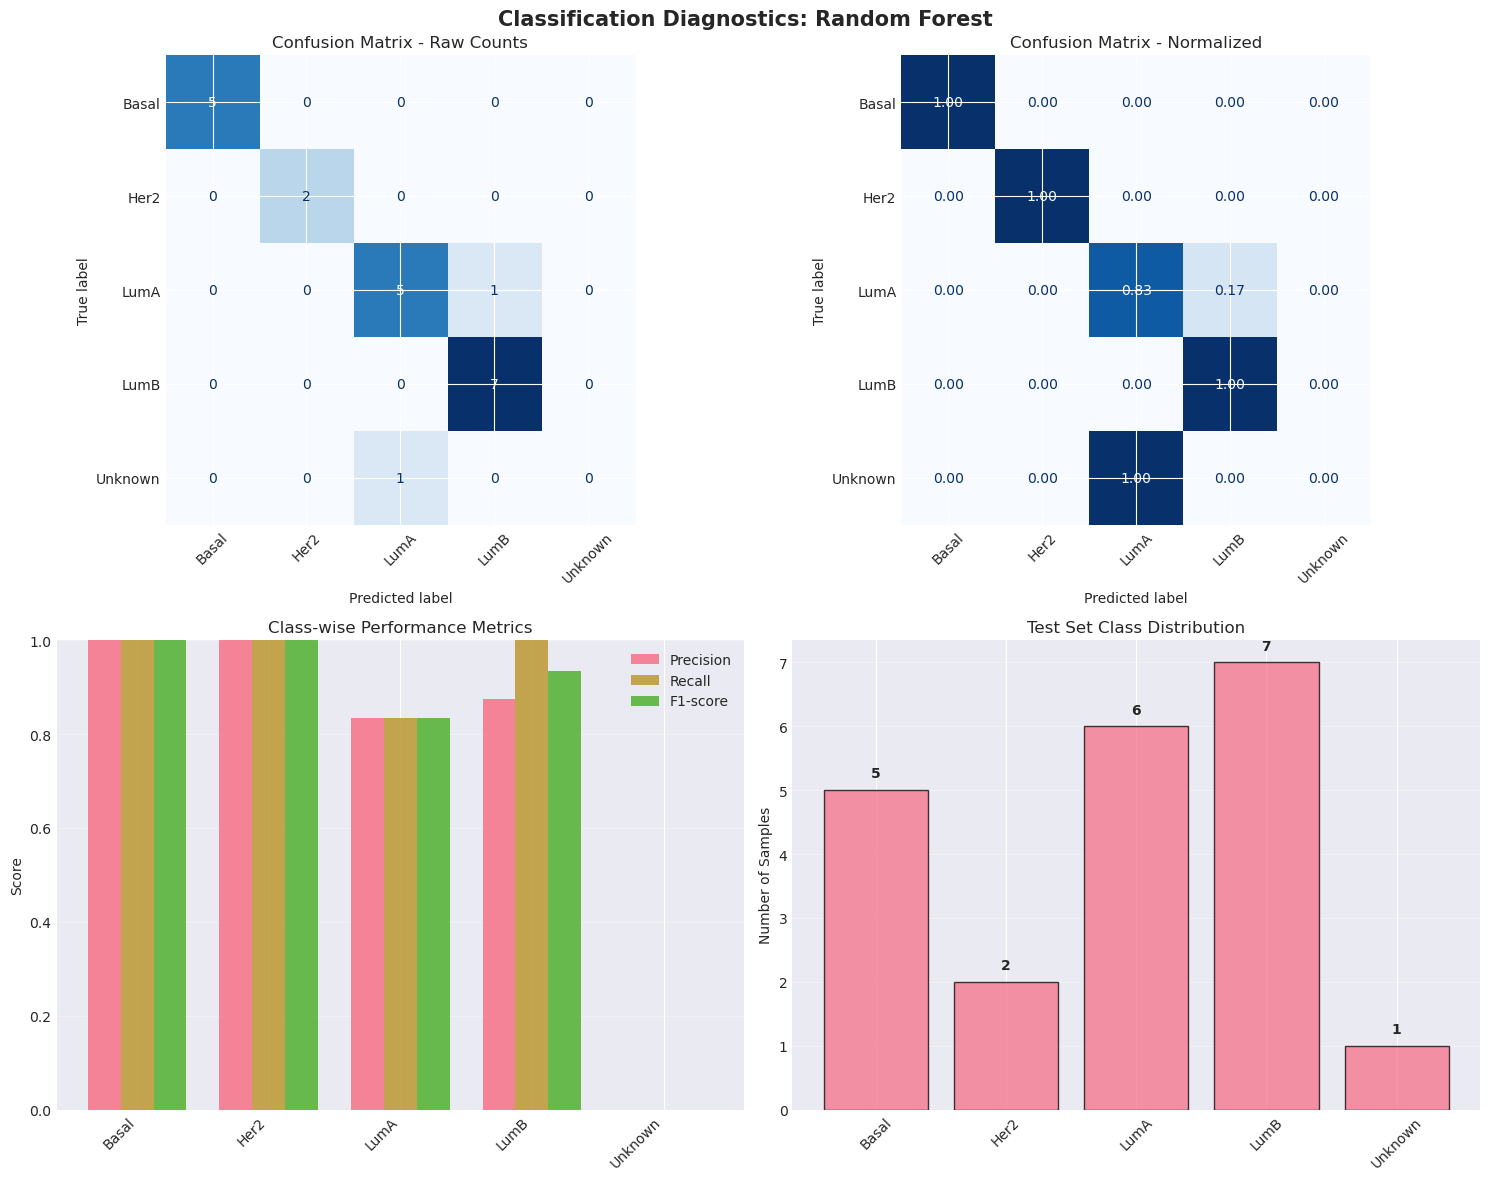


Class-wise Performance Metrics:


,Class,Precision,Recall,F1_score,Support
0,Basal,1.000000,1.000000,1.000000,5
1,Her2,1.000000,1.000000,1.000000,2
2,LumA,0.833333,0.833333,0.833333,6
3,LumB,0.875000,1.000000,0.933333,7
4,Unknown,0.000000,0.000000,0.000000,1



Classification Report:
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         5
        Her2       1.00      1.00      1.00         2
        LumA       0.83      0.83      0.83         6
        LumB       0.88      1.00      0.93         7
     Unknown       0.00      0.00      0.00         1

    accuracy                           0.90        21
   macro avg       0.74      0.77      0.75        21
weighted avg       0.86      0.90      0.88        21


Computing multiclass ROC-AUC...


,Model,ROC_AUC_OVR_weighted,ROC_AUC_OVO_weighted
0,Random Forest,0.938095,0.904053


✓ ROC-AUC OVR weighted: 0.938
✓ ROC-AUC OVO weighted: 0.904

Classification Quality by Class:
  ✓ Best classified subtype: Basal
  ⚠️ Most difficult subtype: Unknown

Confusion Analysis:
  Unknown is most often confused with LumA: 100.0%

✓ Confusion matrix analysis complete.
✓ Figures saved to: /mnt/c/TCGA_cancer/results/figures
✓ Tables saved to: /mnt/c/TCGA_cancer/results/tables


In [15]:
# ============================================================
# 16C. Confusion Matrix and Detailed ML Diagnostics
# Robust version compatible with different column/model names
# ============================================================

print("DETAILED ML DIAGNOSTICS & CONFUSION MATRICES")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check required objects
# ------------------------------------------------------------

required_objects = [
    "improved_ml_results_df",
    "trained_ml_models",
    "X_test_selected",
    "y_test",
    "le_ml"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    print("⚠️ Missing required objects:")
    for obj in missing_objects:
        print(f"  - {obj}")
    print("\nPlease run the improved ML classification section first.")

elif improved_ml_results_df is None or improved_ml_results_df.empty:
    print("⚠️ No ML classification results available.")

else:
    # ------------------------------------------------------------
    # 2. Detect metric column robustly
    # ------------------------------------------------------------

    metric_col = None
    for candidate in ["F1_score", "F1-Score", "F1", "Accuracy"]:
        if candidate in improved_ml_results_df.columns:
            metric_col = candidate
            break

    if metric_col is None:
        raise ValueError(
            "No suitable metric column found. Expected one of: "
            "F1_score, F1-Score, F1, Accuracy"
        )

    # ------------------------------------------------------------
    # 3. Detect model name column robustly
    # ------------------------------------------------------------

    model_col = None
    for candidate in ["Model", "Classifier"]:
        if candidate in improved_ml_results_df.columns:
            model_col = candidate
            break

    if model_col is None:
        raise ValueError(
            "No suitable model name column found. Expected: Model or Classifier"
        )

    # ------------------------------------------------------------
    # 4. Select best model
    # ------------------------------------------------------------

    best_model_name = improved_ml_results_df.loc[
        improved_ml_results_df[metric_col].idxmax(),
        model_col
    ]

    print(f"Selected metric: {metric_col}")
    print(f"Selected model column: {model_col}")
    print(f"Best model: {best_model_name}")
    print()

    print("Available trained models:")
    print(list(trained_ml_models.keys()))
    print()

    best_clf = trained_ml_models.get(best_model_name)

    if best_clf is None:
        print("⚠️ Best model was not found in trained_ml_models.")
        print("This usually means model names in the results table and dictionary do not match.")
        print("Available models:", list(trained_ml_models.keys()))

    else:
        print("✓ Best model found successfully.")

        # ------------------------------------------------------------
        # 5. Predict test labels
        # ------------------------------------------------------------

        y_pred_best = best_clf.predict(X_test_selected)

        class_names = list(le_ml.classes_)

        # Important: use only labels present in y_test/y_pred
        present_labels = np.unique(np.concatenate([y_test, y_pred_best]))
        present_class_names = [class_names[i] for i in present_labels]

        # ------------------------------------------------------------
        # 6. Confusion matrices
        # ------------------------------------------------------------

        cm = confusion_matrix(
            y_test,
            y_pred_best,
            labels=present_labels
        )

        cm_norm = confusion_matrix(
            y_test,
            y_pred_best,
            labels=present_labels,
            normalize="true"
        )

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(
            f"Classification Diagnostics: {best_model_name}",
            fontsize=15,
            fontweight="bold"
        )

        # Raw confusion matrix
        disp_raw = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=present_class_names
        )
        disp_raw.plot(
            ax=axes[0, 0],
            cmap="Blues",
            values_format="d",
            colorbar=False
        )
        axes[0, 0].set_title("Confusion Matrix - Raw Counts")
        axes[0, 0].tick_params(axis="x", rotation=45)

        # Normalized confusion matrix
        disp_norm = ConfusionMatrixDisplay(
            confusion_matrix=cm_norm,
            display_labels=present_class_names
        )
        disp_norm.plot(
            ax=axes[0, 1],
            cmap="Blues",
            values_format=".2f",
            colorbar=False
        )
        axes[0, 1].set_title("Confusion Matrix - Normalized")
        axes[0, 1].tick_params(axis="x", rotation=45)

        # ------------------------------------------------------------
        # 7. Classification report
        # ------------------------------------------------------------

        report = classification_report(
            y_test,
            y_pred_best,
            labels=present_labels,
            target_names=present_class_names,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report).transpose()

        class_metrics_df = report_df.loc[present_class_names, [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]].reset_index()

        class_metrics_df.columns = [
            "Class",
            "Precision",
            "Recall",
            "F1_score",
            "Support"
        ]

        class_metrics_df["Support"] = class_metrics_df["Support"].astype(int)

        # Class-wise metrics plot
        x_pos = np.arange(len(class_metrics_df))
        width = 0.25

        axes[1, 0].bar(
            x_pos - width,
            class_metrics_df["Precision"],
            width,
            label="Precision",
            alpha=0.85
        )

        axes[1, 0].bar(
            x_pos,
            class_metrics_df["Recall"],
            width,
            label="Recall",
            alpha=0.85
        )

        axes[1, 0].bar(
            x_pos + width,
            class_metrics_df["F1_score"],
            width,
            label="F1-score",
            alpha=0.85
        )

        axes[1, 0].set_ylabel("Score")
        axes[1, 0].set_title("Class-wise Performance Metrics")
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(
            class_metrics_df["Class"],
            rotation=45,
            ha="right"
        )
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3, axis="y")

        # Test class distribution
        axes[1, 1].bar(
            class_metrics_df["Class"],
            class_metrics_df["Support"],
            edgecolor="black",
            alpha=0.75
        )

        axes[1, 1].set_ylabel("Number of Samples")
        axes[1, 1].set_title("Test Set Class Distribution")
        axes[1, 1].tick_params(axis="x", rotation=45)
        axes[1, 1].grid(alpha=0.3, axis="y")

        for i, v in enumerate(class_metrics_df["Support"]):
            axes[1, 1].text(
                i,
                v + 0.2,
                str(v),
                ha="center",
                fontweight="bold"
            )

        plt.tight_layout()

        fig_png = FIGURES_DIR / "06_ml_confusion_matrices.png"
        fig_pdf = FIGURES_DIR / "06_ml_confusion_matrices.pdf"

        plt.savefig(fig_png, dpi=300, bbox_inches="tight")
        plt.savefig(fig_pdf, bbox_inches="tight")
        display(fig)
        plt.close()

        # ------------------------------------------------------------
        # 8. Save class metrics
        # ------------------------------------------------------------

        class_metrics_df.to_csv(
            TABLES_DIR / "ml_class_metrics_best_model.csv",
            index=False
        )

        report_df.to_csv(
            TABLES_DIR / "ml_classification_report_best_model.csv"
        )

        print("\nClass-wise Performance Metrics:")
        display(class_metrics_df)

        print("\nClassification Report:")
        print(
            classification_report(
                y_test,
                y_pred_best,
                labels=present_labels,
                target_names=present_class_names,
                zero_division=0
            )
        )

        # ------------------------------------------------------------
        # 9. ROC-AUC if available
        # ------------------------------------------------------------

        roc_auc_summary = None

        if hasattr(best_clf, "predict_proba"):
            print("\nComputing multiclass ROC-AUC...")

            try:
                y_pred_proba = best_clf.predict_proba(X_test_selected)

                # Use labels/classes that are present in the fitted model
                roc_auc_ovr = roc_auc_score(
                    y_test,
                    y_pred_proba,
                    multi_class="ovr",
                    average="weighted"
                )

                roc_auc_ovo = roc_auc_score(
                    y_test,
                    y_pred_proba,
                    multi_class="ovo",
                    average="weighted"
                )

                roc_auc_summary = pd.DataFrame({
                    "Model": [best_model_name],
                    "ROC_AUC_OVR_weighted": [roc_auc_ovr],
                    "ROC_AUC_OVO_weighted": [roc_auc_ovo]
                })

                display(roc_auc_summary)

                roc_auc_summary.to_csv(
                    TABLES_DIR / "ml_best_model_roc_auc.csv",
                    index=False
                )

                print(f"✓ ROC-AUC OVR weighted: {roc_auc_ovr:.3f}")
                print(f"✓ ROC-AUC OVO weighted: {roc_auc_ovo:.3f}")

            except Exception as e:
                print(f"⚠️ Could not compute multiclass ROC-AUC: {e}")

        else:
            print("\n⚠️ Best model does not support predict_proba. ROC-AUC skipped.")

        # ------------------------------------------------------------
        # 10. Best/worst class interpretation
        # ------------------------------------------------------------

        if not class_metrics_df.empty:
            best_class = class_metrics_df.loc[
                class_metrics_df["F1_score"].idxmax(),
                "Class"
            ]

            worst_class = class_metrics_df.loc[
                class_metrics_df["F1_score"].idxmin(),
                "Class"
            ]

            print("\nClassification Quality by Class:")
            print(f"  ✓ Best classified subtype: {best_class}")
            print(f"  ⚠️ Most difficult subtype: {worst_class}")

        # ------------------------------------------------------------
        # 11. Confusion interpretation
        # ------------------------------------------------------------

        print("\nConfusion Analysis:")

        for i, true_class in enumerate(present_class_names):
            row = cm_norm[i, :]

            if np.all(np.isnan(row)):
                continue

            pred_idx = np.nanargmax(row)

            if pred_idx != i:
                confusion_rate = row[pred_idx]
                pred_class = present_class_names[pred_idx]

                print(
                    f"  {true_class} is most often confused with "
                    f"{pred_class}: {confusion_rate * 100:.1f}%"
                )

        print("\n✓ Confusion matrix analysis complete.")
        print(f"✓ Figures saved to: {FIGURES_DIR}")
        print(f"✓ Tables saved to: {TABLES_DIR}")

## Section 16D: Feature Importance and Biological Interpretation
Identify genes contributing most strongly to subtype prediction across different machine learning models.

FEATURE IMPORTANCE AND BIOLOGICAL INTERPRETATION

Extracting Random Forest Feature Importance...
✓ Top 10 Random Forest genes:
              Gene  Importance
 ENSG00000124249.7    0.018562
ENSG00000136883.14    0.014410
 ENSG00000054598.9    0.014285
ENSG00000115648.14    0.014064
 ENSG00000109436.8    0.013708
ENSG00000141738.14    0.013261
ENSG00000144218.19    0.012896
 ENSG00000198729.5    0.012887
ENSG00000157303.11    0.012565
 ENSG00000163661.4    0.012513

Extracting XGBoost Feature Importance...
✓ Top 10 XGBoost genes:
              Gene  Importance
 ENSG00000129514.8    0.051913
 ENSG00000258616.5    0.037746
ENSG00000157765.13    0.034548
 ENSG00000137440.5    0.031262
ENSG00000118849.10    0.029890
 ENSG00000129151.9    0.027951
ENSG00000160180.15    0.024664
ENSG00000064787.13    0.024229
ENSG00000112936.19    0.023197
 ENSG00000230873.9    0.022550

Extracting Logistic Regression Coefficients...
✓ Top 10 Logistic Regression genes (by coef magnitude):
              Gene  C

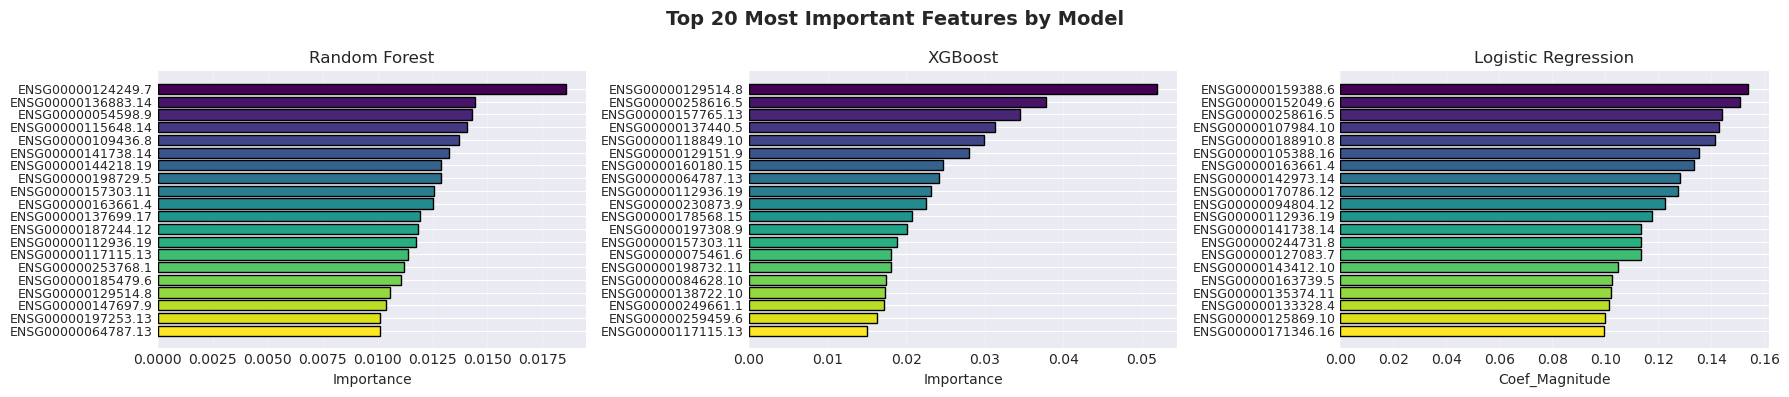


Identifying overlapping important genes across models...

✓ Genes in top 20 of ALL models: 1
  - ENSG00000112936.19

BIOLOGICAL INTERPRETATION

Key findings:
• The above genes represent transcriptomic signatures strongly associated with
  PAM50 subtype distinction in breast cancer.

• Known PAM50 genes (ESR1, ERBB2, TP53, etc.) should appear if data quality is high.

• Gene identifiers appear to be: Ensembl IDs

• Important caveat: Feature importance does NOT imply biological causation;
  it reflects predictive correlation in this dataset.

✓ Feature importance analysis complete


In [16]:
print("FEATURE IMPORTANCE AND BIOLOGICAL INTERPRETATION")
print("=" * 60)

if 'trained_ml_models' not in locals() or not trained_ml_models:
    print("⚠️  No trained ML models found - skipping feature importance analysis")
else:
    all_feature_importances = {}
    feature_names = selected_gene_names_ml if 'selected_gene_names_ml' in locals() else expr_top.columns.tolist()
    
    # ========================================
    # Random Forest feature importance
    # ========================================
    if 'Random Forest' in trained_ml_models:
        print("\nExtracting Random Forest Feature Importance...")
        rf_model = trained_ml_models['Random Forest']
        
        if hasattr(rf_model, 'feature_importances_'):
            rf_importance = pd.DataFrame({
                'Gene': feature_names,
                'Importance': rf_model.feature_importances_
            }).sort_values('Importance', ascending=False)
            
            all_feature_importances['Random Forest'] = rf_importance
            print(f"✓ Top 10 Random Forest genes:")
            print(rf_importance.head(10).to_string(index=False))
    
    # ========================================
    # XGBoost feature importance
    # ========================================
    if XGBOOST_AVAILABLE and 'XGBoost' in trained_ml_models:
        print("\nExtracting XGBoost Feature Importance...")
        xgb_model = trained_ml_models['XGBoost']
        
        if hasattr(xgb_model, 'feature_importances_'):
            xgb_importance = pd.DataFrame({
                'Gene': feature_names,
                'Importance': xgb_model.feature_importances_
            }).sort_values('Importance', ascending=False)
            
            all_feature_importances['XGBoost'] = xgb_importance
            print(f"✓ Top 10 XGBoost genes:")
            print(xgb_importance.head(10).to_string(index=False))
    
    # ========================================
    # Logistic Regression coefficients
    # ========================================
    if 'Logistic Regression' in trained_ml_models:
        print("\nExtracting Logistic Regression Coefficients...")
        lr_model = trained_ml_models['Logistic Regression']
        
        if hasattr(lr_model, 'coef_'):
            # For multiclass, average absolute coefficient magnitude
            if lr_model.coef_.ndim == 2:
                coef_magnitude = np.abs(lr_model.coef_).mean(axis=0)
            else:
                coef_magnitude = np.abs(lr_model.coef_[0])
            
            lr_importance = pd.DataFrame({
                'Gene': feature_names,
                'Coef_Magnitude': coef_magnitude
            }).sort_values('Coef_Magnitude', ascending=False)
            
            all_feature_importances['Logistic Regression'] = lr_importance
            print(f"✓ Top 10 Logistic Regression genes (by coef magnitude):")
            print(lr_importance.head(10).to_string(index=False))
    
    # ========================================
    # Save feature importance tables
    # ========================================
    print()
    print("Saving feature importance tables...")
    
    for model_name, importance_df in all_feature_importances.items():
        importance_df.head(20).to_csv(
            TABLES_DIR / f"feature_importance_top20_{model_name.lower().replace(' ', '_')}.csv",
            index=False
        )
    
    # ========================================
    # Visualization: Top 20 genes for each model
    # ========================================
    print("Creating feature importance visualizations...")
    
    n_models = len(all_feature_importances)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    fig.suptitle('Top 20 Most Important Features by Model', fontsize=14, fontweight='bold')
    
    if n_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_models > 1 else [axes]
    
    for idx, (model_name, importance_df) in enumerate(all_feature_importances.items()):
        if idx < len(axes):
            ax = axes[idx]
            top_20 = importance_df.head(20)
            
            # Get importance column name
            importance_col = top_20.columns[1]
            
            colors = plt.cm.viridis(np.linspace(0, 1, len(top_20)))
            ax.barh(range(len(top_20)), top_20[importance_col].values, color=colors, edgecolor='black')
            ax.set_yticks(range(len(top_20)))
            ax.set_yticklabels(top_20['Gene'].values, fontsize=9)
            ax.set_xlabel(importance_col)
            ax.set_title(f'{model_name}')
            ax.invert_yaxis()
            ax.grid(alpha=0.3, axis='x')
    
    # Hide unused subplots
    for idx in range(len(all_feature_importances), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "07_feature_importance.png", dpi=300, bbox_inches='tight')
    plt.savefig(FIGURES_DIR / "07_feature_importance.pdf", bbox_inches='tight')
    display(fig)
    plt.close()
    
    # ========================================
    # Find overlapping important genes
    # ========================================
    print()
    print("Identifying overlapping important genes across models...")
    
    top_n = 20
    consensus_genes = {}
    
    for model_name, importance_df in all_feature_importances.items():
        consensus_genes[model_name] = set(importance_df.head(top_n)['Gene'].values)
    
    # Find genes in multiple models
    if len(consensus_genes) > 1:
        all_consensus = set.intersection(*consensus_genes.values())
        
        print(f"\n✓ Genes in top {top_n} of ALL models: {len(all_consensus)}")
        if all_consensus:
            for gene in sorted(all_consensus):
                print(f"  - {gene}")
    
    # ========================================
    # Biological Interpretation
    # ========================================
    print()
    print("=" * 60)
    print("BIOLOGICAL INTERPRETATION")
    print("=" * 60)
    print()
    print("Key findings:")
    print("• The above genes represent transcriptomic signatures strongly associated with")
    print("  PAM50 subtype distinction in breast cancer.")
    print()
    print("• Known PAM50 genes (ESR1, ERBB2, TP53, etc.) should appear if data quality is high.")
    print()
    print("• Gene identifiers appear to be:", 
          "Ensembl IDs" if feature_names[0].startswith('ENSG') else 
          "Gene symbols" if len(feature_names[0]) < 10 else "Unknown")
    print()
    print("• Important caveat: Feature importance does NOT imply biological causation;")
    print("  it reflects predictive correlation in this dataset.")
    print()
    print("✓ Feature importance analysis complete")

## Section 17: Survival Analysis
Investigate relationships between gene expression and patient survival using Kaplan-Meier curves and Cox proportional hazards models.

SURVIVAL ANALYSIS
✓ Lifelines available - proceeding with survival analysis

Detecting survival columns...
  Time column: OS.time
  Event column: OS

Matched samples: 69 / 82

Selecting genes for survival analysis...
⚠️ Known gene symbols not found.
This is expected if expression columns are Ensembl IDs.
Using top variable genes instead.
Analyzing 5 genes

Complete cases: 82
Events: 13

Performing Kaplan-Meier and Cox analyses...


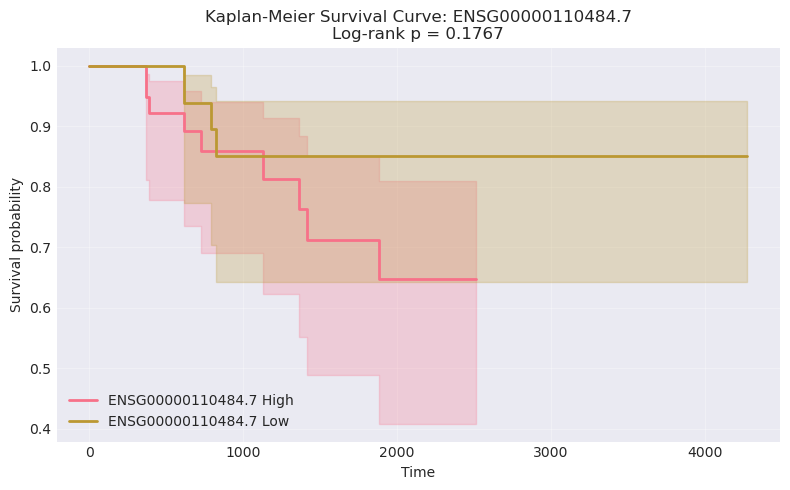

✓ ENSG00000110484.7: log-rank p=0.1767, Cox HR=1.057, Cox p=0.3956


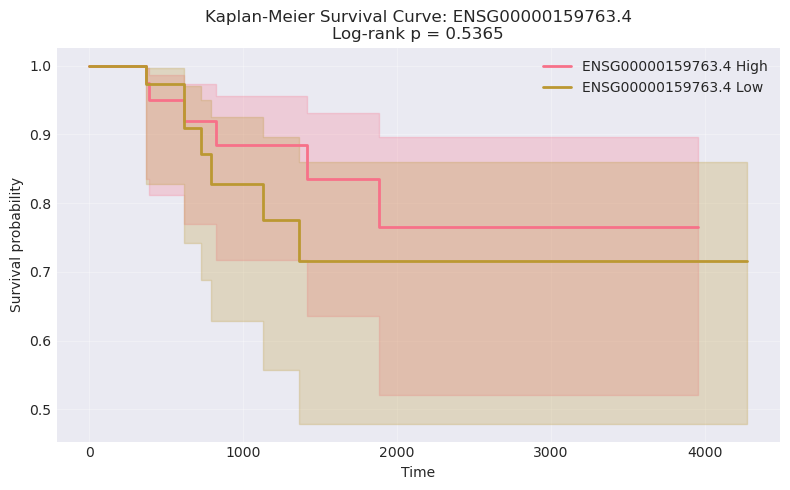

✓ ENSG00000159763.4: log-rank p=0.5365, Cox HR=0.948, Cox p=0.3906


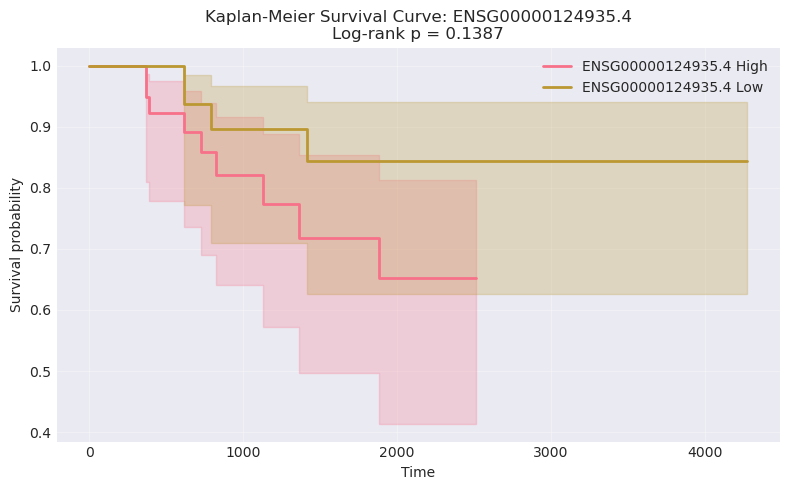

✓ ENSG00000124935.4: log-rank p=0.1387, Cox HR=1.060, Cox p=0.393


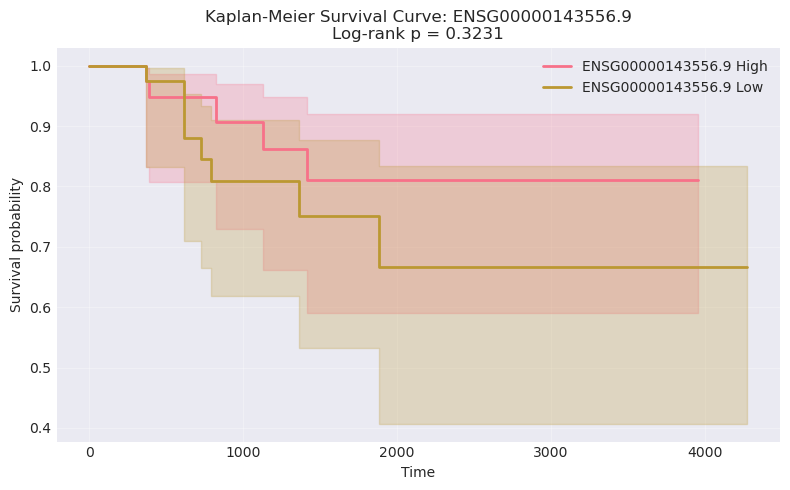

✓ ENSG00000143556.9: log-rank p=0.3231, Cox HR=0.982, Cox p=0.802


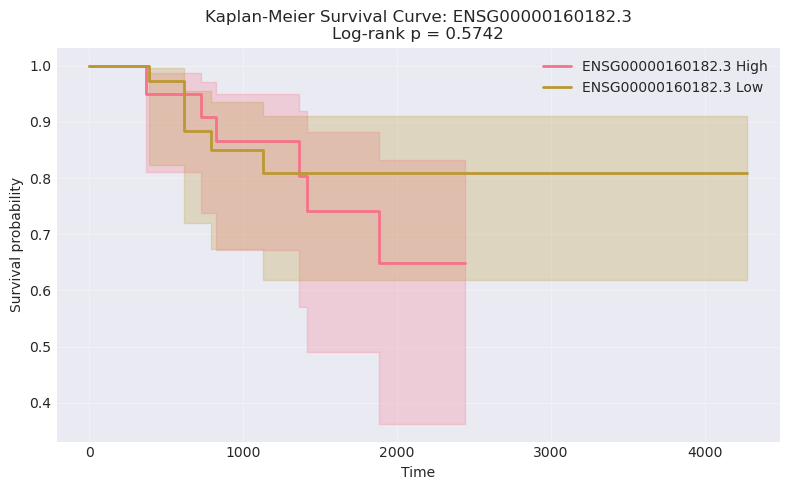

✓ ENSG00000160182.3: log-rank p=0.5742, Cox HR=1.010, Cox p=0.8821

Survival Analysis Results:


,Gene,N_Samples,N_Events,Median_Expression,High_Group_N,Low_Group_N,LogRank_pvalue,Cox_coef,Cox_HR,Cox_HR_95CI_lower,Cox_HR_95CI_upper,Cox_pvalue,Significant_LogRank_p05,Significant_Cox_p05
2,ENSG00000124935.4,82,13,6.632325,41,41,0.138743,0.058343,1.060079,0.927255,1.211930,0.392999,No,No
0,ENSG00000110484.7,82,13,8.351776,41,41,0.176699,0.055278,1.056835,0.930289,1.200594,0.395606,No,No
3,ENSG00000143556.9,82,13,1.494595,41,41,0.323057,-0.018214,0.981950,0.851637,1.132204,0.802020,No,No
1,ENSG00000159763.4,82,13,7.168813,41,41,0.536518,-0.053723,0.947694,0.838301,1.071363,0.390631,No,No
4,ENSG00000160182.3,82,13,6.692183,41,41,0.574155,0.009904,1.009953,0.886015,1.151228,0.882136,No,No



✓ Most survival-associated gene by log-rank test: ENSG00000124935.4 (p=0.1387)
Genes significant by log-rank p<0.05: 0/5
Genes significant by Cox p<0.05: 0/5

✓ Survival analysis complete.


In [17]:
print("SURVIVAL ANALYSIS")
print("=" * 60)

if not LIFELINES_AVAILABLE:
    print("⚠️ Lifelines not installed - survival analysis skipped")
    print("Install with: pip install lifelines")

elif surv is None:
    print("⚠️ Survival data not available - skipping survival analysis")

else:
    print("✓ Lifelines available - proceeding with survival analysis\n")

    # ------------------------------------------------------------
    # 1. Detect survival columns robustly
    # ------------------------------------------------------------
    print("Detecting survival columns...")

    if "OS.time" in surv.columns and "OS" in surv.columns:
        detected_time_col = "OS.time"
        detected_event_col = "OS"
    else:
        detected_time_col = None
        detected_event_col = None

        for col in surv.columns:
            col_lower = col.lower()

            if detected_time_col is None and (
                "time" in col_lower or "follow" in col_lower
            ):
                detected_time_col = col

            if detected_event_col is None and (
                "event" in col_lower or
                "status" in col_lower or
                "death" in col_lower
            ):
                detected_event_col = col

    print(f"  Time column: {detected_time_col}")
    print(f"  Event column: {detected_event_col}\n")

    if detected_time_col is None or detected_event_col is None:
        print("⚠️ Could not detect survival columns - skipping survival analysis")

    else:
        # ------------------------------------------------------------
        # 2. Prepare survival dataframe
        # ------------------------------------------------------------
        surv_analysis = surv[[detected_time_col, detected_event_col]].copy()
        surv_analysis.columns = ["time", "event"]

        surv_analysis["time"] = pd.to_numeric(surv_analysis["time"], errors="coerce")
        surv_analysis["event"] = pd.to_numeric(surv_analysis["event"], errors="coerce")

        surv_analysis = surv_analysis.dropna(subset=["time", "event"])
        surv_analysis = surv_analysis[surv_analysis["time"] > 0]

        # Event must be 0/1
        surv_analysis["event"] = surv_analysis["event"].astype(int)

        # ------------------------------------------------------------
        # 3. Match samples
        # ------------------------------------------------------------
        common_samples_surv = expr.index.intersection(surv_analysis.index)

        print(f"Matched samples: {len(common_samples_surv)} / {expr.shape[0]}\n")

        if len(common_samples_surv) < 10:
            print("⚠️ Too few matched samples for survival analysis")

        else:
            # ------------------------------------------------------------
            # 4. Select genes
            # ------------------------------------------------------------
            print("Selecting genes for survival analysis...")

            known_genes = [
                "MKI67", "ERBB2", "ESR1", "PGR",
                "TP53", "BRCA1", "BRCA2"
            ]

            available_genes = [g for g in known_genes if g in expr.columns]

            if available_genes:
                survival_genes = available_genes
                print(f"✓ Found known breast cancer genes: {survival_genes}")
            else:
                print("⚠️ Known gene symbols not found.")
                print("This is expected if expression columns are Ensembl IDs.")
                print("Using top variable genes instead.")
                survival_genes = expr_top.columns[:5].tolist()

            print(f"Analyzing {len(survival_genes)} genes\n")

            # ------------------------------------------------------------
            # 5. Build analysis dataframe
            # ------------------------------------------------------------
            surv_expr = expr.loc[common_samples_surv, survival_genes].copy()
            surv_data = surv_analysis.loc[common_samples_surv].copy()

            surv_df = pd.concat([surv_data, surv_expr], axis=1)
            surv_df = surv_df.replace([np.inf, -np.inf], np.nan)
            surv_df = surv_df.dropna()

            print(f"Complete cases: {len(surv_df)}")
            print(f"Events: {int(surv_df['event'].sum())}\n")

            if surv_df["event"].sum() < 5:
                print("⚠️ Very few events. Survival results will be unstable.")

            # ------------------------------------------------------------
            # 6. Kaplan-Meier + Cox model
            # ------------------------------------------------------------
            print("Performing Kaplan-Meier and Cox analyses...")

            survival_results = []

            for gene in survival_genes:
                try:
                    gene_df = surv_df[["time", "event", gene]].copy()
                    gene_df = gene_df.dropna()

                    if gene_df[gene].nunique() < 2:
                        print(f"⚠️ Skipping {gene}: expression has <2 unique values")
                        continue

                    median_expr = gene_df[gene].median()
                    gene_df["group"] = np.where(
                        gene_df[gene] >= median_expr,
                        "High",
                        "Low"
                    )

                    high_df = gene_df[gene_df["group"] == "High"]
                    low_df = gene_df[gene_df["group"] == "Low"]

                    if len(high_df) < 5 or len(low_df) < 5:
                        print(f"⚠️ Skipping {gene}: too few samples in high/low groups")
                        continue

                    # Kaplan-Meier plot
                    fig_km, ax_km = plt.subplots(figsize=(8, 5))

                    kmf_high = KaplanMeierFitter()
                    kmf_low = KaplanMeierFitter()

                    kmf_high.fit(
                        durations=high_df["time"],
                        event_observed=high_df["event"],
                        label=f"{gene} High"
                    )

                    kmf_low.fit(
                        durations=low_df["time"],
                        event_observed=low_df["event"],
                        label=f"{gene} Low"
                    )

                    kmf_high.plot_survival_function(ax=ax_km, linewidth=2)
                    kmf_low.plot_survival_function(ax=ax_km, linewidth=2)

                    # Log-rank test
                    logrank_res = logrank_test(
                        high_df["time"],
                        low_df["time"],
                        event_observed_A=high_df["event"],
                        event_observed_B=low_df["event"]
                    )

                    logrank_pvalue = logrank_res.p_value

                    ax_km.set_title(
                        f"Kaplan-Meier Survival Curve: {gene}\n"
                        f"Log-rank p = {logrank_pvalue:.4g}"
                    )
                    ax_km.set_xlabel("Time")
                    ax_km.set_ylabel("Survival probability")
                    ax_km.grid(alpha=0.3)
                    ax_km.legend()

                    plt.tight_layout()
                    plt.savefig(
                        FIGURES_DIR / f"08_km_curve_{gene}.png",
                        dpi=300,
                        bbox_inches="tight"
                    )
                    plt.savefig(
                        FIGURES_DIR / f"08_km_curve_{gene}.pdf",
                        bbox_inches="tight"
                    )
                    display(fig_km)
                    plt.close(fig_km)

                    # Cox proportional hazards model
                    cph = CoxPHFitter()
                    cox_input = gene_df[["time", "event", gene]].copy()

                    cph.fit(
                        cox_input,
                        duration_col="time",
                        event_col="event"
                    )

                    # Robust extraction from cph.summary
                    cox_summary = cph.summary.copy()

                    if gene in cox_summary.index:
                        cox_hr = cox_summary.loc[gene, "exp(coef)"]
                        cox_pvalue = cox_summary.loc[gene, "p"]
                        cox_coef = cox_summary.loc[gene, "coef"]
                        cox_ci_lower = cox_summary.loc[gene, "exp(coef) lower 95%"]
                        cox_ci_upper = cox_summary.loc[gene, "exp(coef) upper 95%"]
                    else:
                        # Fallback: first row
                        cox_hr = cox_summary["exp(coef)"].iloc[0]
                        cox_pvalue = cox_summary["p"].iloc[0]
                        cox_coef = cox_summary["coef"].iloc[0]
                        cox_ci_lower = cox_summary["exp(coef) lower 95%"].iloc[0]
                        cox_ci_upper = cox_summary["exp(coef) upper 95%"].iloc[0]

                    survival_results.append({
                        "Gene": gene,
                        "N_Samples": len(gene_df),
                        "N_Events": int(gene_df["event"].sum()),
                        "Median_Expression": median_expr,
                        "High_Group_N": len(high_df),
                        "Low_Group_N": len(low_df),
                        "LogRank_pvalue": logrank_pvalue,
                        "Cox_coef": cox_coef,
                        "Cox_HR": cox_hr,
                        "Cox_HR_95CI_lower": cox_ci_lower,
                        "Cox_HR_95CI_upper": cox_ci_upper,
                        "Cox_pvalue": cox_pvalue,
                        "Significant_LogRank_p05": "Yes" if logrank_pvalue < 0.05 else "No",
                        "Significant_Cox_p05": "Yes" if cox_pvalue < 0.05 else "No"
                    })

                    print(
                        f"✓ {gene}: "
                        f"log-rank p={logrank_pvalue:.4g}, "
                        f"Cox HR={cox_hr:.3f}, "
                        f"Cox p={cox_pvalue:.4g}"
                    )

                except Exception as e:
                    print(f"⚠️ Survival analysis failed for {gene}: {e}")

            # ------------------------------------------------------------
            # 7. Save and summarize results
            # ------------------------------------------------------------
            if len(survival_results) == 0:
                print("\n⚠️ No valid survival results were generated.")

            else:
                survival_results_df = pd.DataFrame(survival_results)
                survival_results_df = survival_results_df.sort_values(
                    "LogRank_pvalue"
                )

                survival_results_df.to_csv(
                    TABLES_DIR / "survival_analysis_results.csv",
                    index=False
                )

                print("\nSurvival Analysis Results:")
                display(survival_results_df)

                best_gene = survival_results_df.iloc[0]["Gene"]
                best_pval = survival_results_df.iloc[0]["LogRank_pvalue"]

                print(
                    f"\n✓ Most survival-associated gene by log-rank test: "
                    f"{best_gene} (p={best_pval:.4g})"
                )

                sig_logrank = (
                    survival_results_df["LogRank_pvalue"] < 0.05
                ).sum()

                sig_cox = (
                    survival_results_df["Cox_pvalue"] < 0.05
                ).sum()

                print(
                    f"Genes significant by log-rank p<0.05: "
                    f"{sig_logrank}/{len(survival_results_df)}"
                )

                print(
                    f"Genes significant by Cox p<0.05: "
                    f"{sig_cox}/{len(survival_results_df)}"
                )

                print("\n✓ Survival analysis complete.")

## Section 18: Deep Learning Preparation
Prepare high-dimensional transcriptomic data for advanced neural network-based analyses.

In [18]:
# ============================================================
# FORCE RECOVERY: reload expression and PAM50 data
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/mnt/c/TCGA_cancer")

EXPRESSION_FILE = BASE_DIR / "TCGA-BRCA.star_tpm.tsv"
PAM50_FILE = BASE_DIR / "brca_pam50"

RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"

for d in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Reloading expression data...")

expr_raw = pd.read_csv(EXPRESSION_FILE, sep="\t", index_col=0)

if expr_raw.shape[0] > expr_raw.shape[1]:
    expr = expr_raw.T
else:
    expr = expr_raw.copy()

expr.index = expr.index.map(lambda x: str(x)[:12])
expr = expr[~expr.index.duplicated(keep="first")]

expr = expr.replace([np.inf, -np.inf], np.nan)
expr = expr.fillna(expr.median())

print("✓ expr reloaded")
print("expr shape:", expr.shape)

print("\nReloading PAM50 data...")

pam50 = pd.read_csv(PAM50_FILE, sep="\t", index_col=0)
pam50.index = pam50.index.map(lambda x: str(x)[:12])
pam50 = pam50[~pam50.index.duplicated(keep="first")]

subtype_col = "PAM50"

print("✓ pam50 reloaded")
print("pam50 shape:", pam50.shape)
print("subtype_col:", subtype_col)
display(pam50[subtype_col].value_counts().to_frame("count"))

print("\n✓ Force recovery complete.")

Reloading expression data...
✓ expr reloaded
expr shape: (1095, 60660)

Reloading PAM50 data...
✓ pam50 reloaded
pam50 shape: (74, 1)
subtype_col: PAM50


,count
PAM50,
LumB,25
LumA,18
Basal,15
Her2,11
Unknown,4
Normal,1



✓ Force recovery complete.


In [19]:
print("DEEP LEARNING BACKEND CHECK")
print("=" * 60)

# TensorFlow causes kernel crash in this environment.
# Therefore, TensorFlow will be disabled and PyTorch will be used instead.

TENSORFLOW_AVAILABLE = False
print("⚠️ TensorFlow disabled because it crashes the Jupyter kernel.")

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    
    PYTORCH_AVAILABLE = True
    print("✓ PyTorch available")
    print("PyTorch version:", torch.__version__)

except Exception as e:
    PYTORCH_AVAILABLE = False
    print("⚠️ PyTorch not available.")
    print("Install with:")
    print("pip install torch torchvision torchaudio")
    print("Error:", e)

DEEP LEARNING BACKEND CHECK
⚠️ TensorFlow disabled because it crashes the Jupyter kernel.
✓ PyTorch available
PyTorch version: 2.11.0+cu130


In [20]:
print("DEEP LEARNING DATA PREPARATION - SELF CONTAINED VERSION")
print("=" * 70)

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ============================================================
# 0. Define paths and output directories
# ============================================================

BASE_DIR = Path("/mnt/c/TCGA_cancer")

EXPRESSION_FILE = BASE_DIR / "TCGA-BRCA.star_tpm.tsv"
PAM50_FILE = BASE_DIR / "brca_pam50"

RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"

DL_MODELS_DIR = MODELS_DIR / "deep_learning"
DL_FIGURES_DIR = FIGURES_DIR / "deep_learning"
DL_TABLES_DIR = TABLES_DIR / "deep_learning"

for directory in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR,
                  DL_MODELS_DIR, DL_FIGURES_DIR, DL_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("✓ Output directories ready")

# ============================================================
# 1. Reload expression data if needed
# ============================================================

if "expr" not in globals():
    print("\nexpr not found. Reloading expression data...")

    expr_raw = pd.read_csv(EXPRESSION_FILE, sep="\t", index_col=0)

    if expr_raw.shape[0] > expr_raw.shape[1]:
        expr = expr_raw.T
    else:
        expr = expr_raw.copy()

    expr.index = expr.index.map(lambda x: str(x)[:12])
    expr = expr[~expr.index.duplicated(keep="first")]

    expr = expr.replace([np.inf, -np.inf], np.nan)
    expr = expr.fillna(expr.median())

    print("✓ expr reloaded:", expr.shape)
else:
    print("✓ expr already exists:", expr.shape)

# ============================================================
# 2. Reload PAM50 data if needed
# ============================================================

if "pam50" not in globals() or "subtype_col" not in globals():
    print("\npam50 not found. Reloading PAM50 data...")

    pam50 = pd.read_csv(PAM50_FILE, sep="\t", index_col=0)
    pam50.index = pam50.index.map(lambda x: str(x)[:12])
    pam50 = pam50[~pam50.index.duplicated(keep="first")]

    subtype_col = "PAM50"

    print("✓ pam50 reloaded:", pam50.shape)
else:
    print("✓ pam50 already exists:", pam50.shape)

# ============================================================
# 3. Select top variable genes
# ============================================================

N_DL_GENES = 2000

print(f"\nSelecting top {N_DL_GENES} variable genes...")

expr_dl = expr.copy()
expr_dl = expr_dl.replace([np.inf, -np.inf], np.nan)
expr_dl = expr_dl.fillna(expr_dl.median())

gene_var = expr_dl.var(axis=0)
top_dl_genes = gene_var.nlargest(min(N_DL_GENES, len(gene_var))).index.tolist()

expr_dl_filtered = expr_dl[top_dl_genes].copy()

print("✓ Selected genes:", len(top_dl_genes))
print("Expression shape:", expr_dl_filtered.shape)

# ============================================================
# 4. Match expression and PAM50 labels
# ============================================================

pam50_unique = pam50.copy()
pam50_unique = pam50_unique[~pam50_unique.index.duplicated(keep="first")]

common_samples_dl = expr_dl_filtered.index.intersection(pam50_unique.index)

print("\nSample matching:")
print("Expression samples:", expr_dl_filtered.shape[0])
print("PAM50 samples:", pam50_unique.shape[0])
print("Common samples:", len(common_samples_dl))

if len(common_samples_dl) < 10:
    raise ValueError("Too few common samples for deep learning.")

dl_df = expr_dl_filtered.loc[common_samples_dl].copy()
dl_df["PAM50_subtype"] = pam50_unique.loc[common_samples_dl, subtype_col]

dl_df = dl_df.dropna(subset=["PAM50_subtype"])

print("\nInitial PAM50 distribution:")
display(dl_df["PAM50_subtype"].value_counts().to_frame("count"))

# ============================================================
# 5. Remove rare classes
# ============================================================

min_class_count = 3

class_counts = dl_df["PAM50_subtype"].value_counts()
valid_classes = class_counts[class_counts >= min_class_count].index
removed_classes = class_counts[class_counts < min_class_count]

if len(removed_classes) > 0:
    print(f"\nRemoving classes with <{min_class_count} samples:")
    display(removed_classes.to_frame("removed_count"))

dl_df = dl_df[dl_df["PAM50_subtype"].isin(valid_classes)].copy()

print("\nFinal PAM50 distribution:")
display(dl_df["PAM50_subtype"].value_counts().to_frame("count"))

if dl_df["PAM50_subtype"].nunique() < 2:
    raise ValueError("Fewer than 2 classes remain after filtering.")

# ============================================================
# 6. Create X and y
# ============================================================

X_dl_df = dl_df.drop(columns=["PAM50_subtype"])
y_labels_dl = dl_df["PAM50_subtype"]

le_dl = LabelEncoder()
y_dl = le_dl.fit_transform(y_labels_dl)

X_dl = X_dl_df.values

print("\nDeep learning input:")
print("Samples:", X_dl.shape[0])
print("Genes:", X_dl.shape[1])
print("Classes:", len(le_dl.classes_))

for i, cls in enumerate(le_dl.classes_):
    print(f"  {i}: {cls}")

# ============================================================
# 7. Robust train / validation / test split
# ============================================================

print("\nPerforming train/validation/test split...")

class_counts_encoded = pd.Series(y_dl).value_counts()

print("\nEncoded class distribution:")
display(class_counts_encoded.sort_index().to_frame("count"))

# First split: train 70%, temp 30%
stratify_first = y_dl if class_counts_encoded.min() >= 2 else None

X_train_dl_raw, X_temp_dl_raw, y_train_dl, y_temp_dl = train_test_split(
    X_dl,
    y_dl,
    test_size=0.30,
    random_state=42,
    stratify=stratify_first
)

# Second split: validation/test
temp_class_counts = pd.Series(y_temp_dl).value_counts()

print("\nTemporary set class distribution:")
display(temp_class_counts.sort_index().to_frame("count"))

if temp_class_counts.min() >= 2 and len(temp_class_counts) >= 2:
    stratify_second = y_temp_dl
    print("✓ Stratified validation/test split used")
else:
    stratify_second = None
    print("⚠️ Validation/test stratification disabled due to very small class counts")

X_val_dl_raw, X_test_dl_raw, y_val_dl, y_test_dl = train_test_split(
    X_temp_dl_raw,
    y_temp_dl,
    test_size=0.50,
    random_state=42,
    stratify=stratify_second
)

print("\nSplit summary:")
print("Train:", X_train_dl_raw.shape[0])
print("Validation:", X_val_dl_raw.shape[0])
print("Test:", X_test_dl_raw.shape[0])

# ============================================================
# 8. Standardization
# ============================================================

scaler_dl = StandardScaler()

X_train_dl = scaler_dl.fit_transform(X_train_dl_raw)
X_val_dl = scaler_dl.transform(X_val_dl_raw)
X_test_dl = scaler_dl.transform(X_test_dl_raw)

print("\n✓ Features standardized")

# ============================================================
# 9. Final checks and save
# ============================================================

assert X_dl.shape[0] == len(y_dl)
assert X_train_dl.shape[0] == len(y_train_dl)
assert X_val_dl.shape[0] == len(y_val_dl)
assert X_test_dl.shape[0] == len(y_test_dl)

prep_info = pd.DataFrame([{
    "n_samples": X_dl.shape[0],
    "n_genes": X_dl.shape[1],
    "n_classes": len(le_dl.classes_),
    "n_train": X_train_dl.shape[0],
    "n_validation": X_val_dl.shape[0],
    "n_test": X_test_dl.shape[0],
    "class_names": ", ".join(le_dl.classes_)
}])

prep_info.to_csv(
    DL_TABLES_DIR / "deep_learning_preparation_summary.csv",
    index=False
)

pd.DataFrame({"selected_gene": top_dl_genes}).to_csv(
    DL_TABLES_DIR / "selected_deep_learning_genes.csv",
    index=False
)

display(prep_info)

dl_ready = True

print("\n✓ Deep learning data preparation completed successfully.")

DEEP LEARNING DATA PREPARATION - SELF CONTAINED VERSION
✓ Output directories ready
✓ expr already exists: (1095, 60660)
✓ pam50 already exists: (74, 1)

Selecting top 2000 variable genes...
✓ Selected genes: 2000
Expression shape: (1095, 2000)

Sample matching:
Expression samples: 1095
PAM50 samples: 74
Common samples: 74

Initial PAM50 distribution:


,count
PAM50_subtype,
LumB,25
LumA,18
Basal,15
Her2,11
Unknown,4
Normal,1



Removing classes with <3 samples:


,removed_count
PAM50_subtype,
Normal,1



Final PAM50 distribution:


...


Temporary set class distribution:


,count
0,5
1,3
2,5
3,8
4,1


⚠️ Validation/test stratification disabled due to very small class counts

Split summary:
Train: 51
Validation: 11
Test: 11

✓ Features standardized


,n_samples,n_genes,n_classes,n_train,n_validation,n_test,class_names
0,73,2000,5,51,11,11,"Basal, Her2, LumA, LumB, Unknown"



✓ Deep learning data preparation completed successfully.


## Section 19: Autoencoder for Latent Representation Learning
Learn compressed representations of high-dimensional transcriptomic data using deep autoencoders.

In [21]:
print("DEEP LEARNING BACKEND CHECK")
print("=" * 60)

# TensorFlow causes kernel crash in this environment.
# Therefore, TensorFlow will be disabled and PyTorch will be used instead.

TENSORFLOW_AVAILABLE = False
print("⚠️ TensorFlow disabled because it crashes the Jupyter kernel.")

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    
    PYTORCH_AVAILABLE = True
    print("✓ PyTorch available")
    print("PyTorch version:", torch.__version__)

except Exception as e:
    PYTORCH_AVAILABLE = False
    print("⚠️ PyTorch not available.")
    print("Install with:")
    print("pip install torch torchvision torchaudio")
    print("Error:", e)

DEEP LEARNING BACKEND CHECK
⚠️ TensorFlow disabled because it crashes the Jupyter kernel.
✓ PyTorch available
PyTorch version: 2.11.0+cu130


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

PYTORCH AUTOENCODER FOR LATENT REPRESENTATION LEARNING
✓ PyTorch available
✓ Device: cpu
Input dimension: 2000
Latent dimension: 32
Batch size: 32

✓ PyTorch autoencoder architecture created

Training PyTorch autoencoder...
Epoch 001 | Train Loss: 1.31776 | Val Loss: 1.05142
Epoch 010 | Train Loss: 0.45588 | Val Loss: 0.89239
Epoch 020 | Train Loss: 0.29640 | Val Loss: 0.85668
Epoch 030 | Train Loss: 0.16068 | Val Loss: 0.88133

✓ Early stopping at epoch 31

✓ Autoencoder training complete


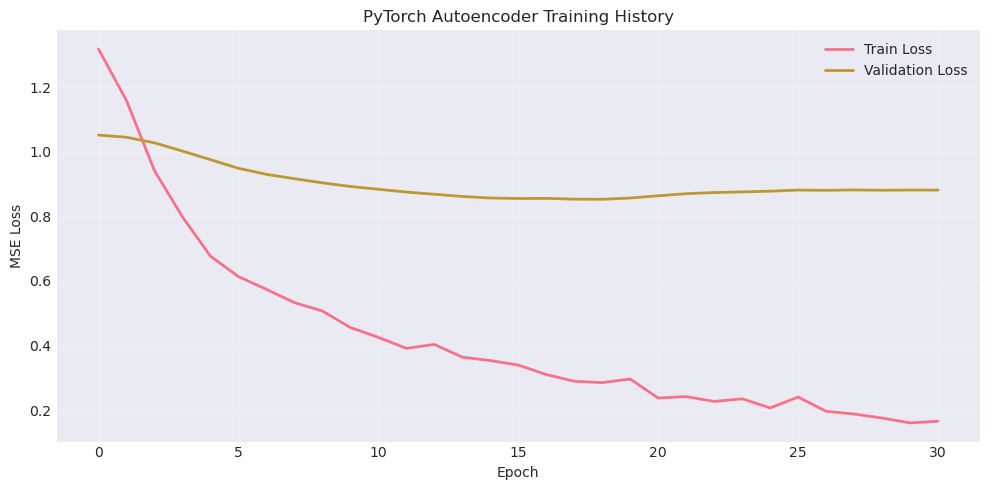


Extracting latent representations...
✓ Latent train shape: (51, 32)
✓ Latent test shape: (11, 32)
✓ Latent all shape: (73, 32)

Visualizing latent space...


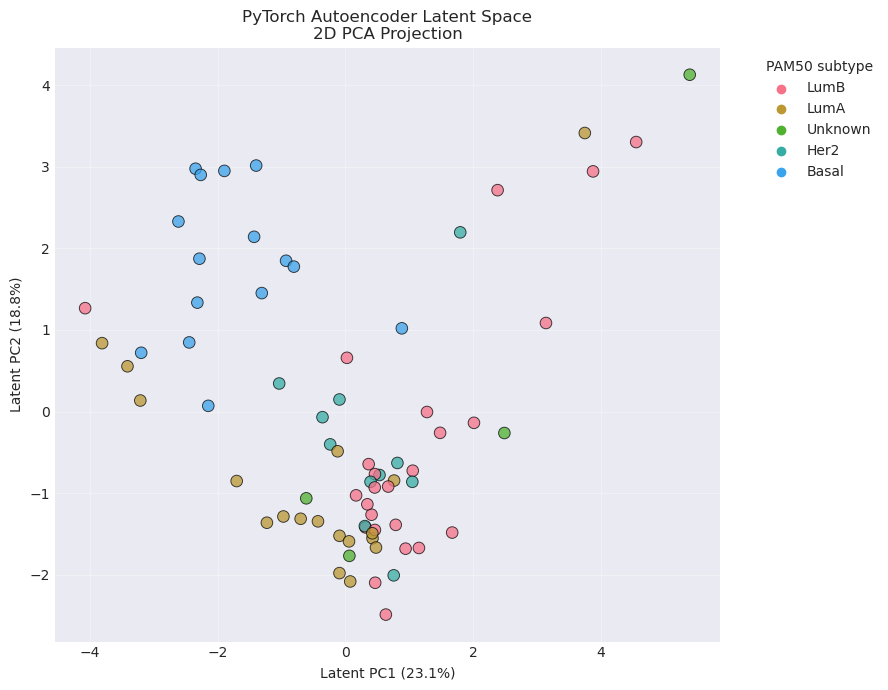


Training classical classifiers on latent representations...
Logistic Regression (Latent): Accuracy=0.636, F1=0.618
Random Forest (Latent): Accuracy=0.818, F1=0.780


,Model,Analysis_Type,Accuracy,Precision,Recall,F1_score
0,Logistic Regression (Latent),Autoencoder latent features,0.636364,0.636364,0.636364,0.618182
1,Random Forest (Latent),Autoencoder latent features,0.818182,0.800000,0.818182,0.780303



INTERPRETATION:
✓ Autoencoder latent space shows strong subtype-discriminative structure.

✓ PyTorch autoencoder analysis complete.


In [23]:
print("PYTORCH AUTOENCODER FOR LATENT REPRESENTATION LEARNING")
print("=" * 70)

# ============================================================
# 0. Backend and data checks
# ============================================================

if "PYTORCH_AVAILABLE" not in globals() or not PYTORCH_AVAILABLE:
    print("⚠️ PyTorch not available - autoencoder skipped")
    print("Install with: pip install torch torchvision torchaudio")

elif "dl_ready" not in globals() or not dl_ready:
    print("⚠️ Deep learning data not prepared - skipping autoencoder")
    print("Please run Section 18: Deep Learning Data Preparation first.")

elif "X_train_dl" not in globals():
    print("⚠️ X_train_dl not found - skipping autoencoder")
    print("Please run the corrected deep learning preparation cell first.")

else:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.decomposition import PCA
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

    # ------------------------------------------------------------
    # 1. Device setup
    # ------------------------------------------------------------

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"✓ PyTorch available")
    print(f"✓ Device: {device}")

    # ------------------------------------------------------------
    # 2. Convert numpy arrays to tensors
    # ------------------------------------------------------------

    X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_dl, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32)
    X_all_tensor = torch.tensor(scaler_dl.transform(X_dl), dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

    batch_size = min(32, X_train_tensor.shape[0])

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    input_dim = X_train_dl.shape[1]
    latent_dim = 32

    print(f"Input dimension: {input_dim}")
    print(f"Latent dimension: {latent_dim}")
    print(f"Batch size: {batch_size}")

    # ------------------------------------------------------------
    # 3. Define PyTorch Autoencoder
    # ------------------------------------------------------------

    class Autoencoder(nn.Module):
        def __init__(self, input_dim, latent_dim=32):
            super(Autoencoder, self).__init__()

            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(0.2),

                nn.Linear(512, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),

                nn.Linear(128, latent_dim),
                nn.ReLU()
            )

            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),

                nn.Linear(128, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),

                nn.Linear(512, input_dim)
            )

        def forward(self, x):
            z = self.encoder(x)
            x_recon = self.decoder(z)
            return x_recon

        def encode(self, x):
            return self.encoder(x)

    autoencoder_pt = Autoencoder(
        input_dim=input_dim,
        latent_dim=latent_dim
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(
        autoencoder_pt.parameters(),
        lr=1e-3,
        weight_decay=1e-5
    )

    print("\n✓ PyTorch autoencoder architecture created")

    # ------------------------------------------------------------
    # 4. Train autoencoder with early stopping
    # ------------------------------------------------------------

    max_epochs = 100
    patience = 12
    best_val_loss = np.inf
    patience_counter = 0

    train_losses = []
    val_losses = []

    print("\nTraining PyTorch autoencoder...")

    for epoch in range(max_epochs):
        autoencoder_pt.train()
        running_train_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            recon = autoencoder_pt(xb)
            loss = criterion(recon, yb)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * xb.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)

        autoencoder_pt.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                recon = autoencoder_pt(xb)
                loss = criterion(recon, yb)

                running_val_loss += loss.item() * xb.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:03d} | "
                f"Train Loss: {epoch_train_loss:.5f} | "
                f"Val Loss: {epoch_val_loss:.5f}"
            )

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0

            torch.save(
                autoencoder_pt.state_dict(),
                DL_MODELS_DIR / "pytorch_autoencoder_best.pt"
            )

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\n✓ Early stopping at epoch {epoch+1}")
            break

    # Load best model
    autoencoder_pt.load_state_dict(
        torch.load(
            DL_MODELS_DIR / "pytorch_autoencoder_best.pt",
            map_location=device
        )
    )

    print("\n✓ Autoencoder training complete")

    # ------------------------------------------------------------
    # 5. Plot reconstruction loss
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(train_losses, label="Train Loss", linewidth=2)
    ax.plot(val_losses, label="Validation Loss", linewidth=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title("PyTorch Autoencoder Training History")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_autoencoder_training_history.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_autoencoder_training_history.pdf",
        bbox_inches="tight"
    )

    display(fig)
    plt.close()

    # ------------------------------------------------------------
    # 6. Extract latent representations
    # ------------------------------------------------------------

    print("\nExtracting latent representations...")

    autoencoder_pt.eval()

    with torch.no_grad():
        latent_train = autoencoder_pt.encode(
            X_train_tensor.to(device)
        ).cpu().numpy()

        latent_val = autoencoder_pt.encode(
            X_val_tensor.to(device)
        ).cpu().numpy()

        latent_test = autoencoder_pt.encode(
            X_test_tensor.to(device)
        ).cpu().numpy()

        latent_all = autoencoder_pt.encode(
            X_all_tensor.to(device)
        ).cpu().numpy()

    print(f"✓ Latent train shape: {latent_train.shape}")
    print(f"✓ Latent test shape: {latent_test.shape}")
    print(f"✓ Latent all shape: {latent_all.shape}")

    # Save latent features
    latent_all_df = pd.DataFrame(
        latent_all,
        columns=[f"Latent_{i+1}" for i in range(latent_all.shape[1])]
    )

    latent_all_df["PAM50_subtype"] = le_dl.inverse_transform(y_dl)

    latent_all_df.to_csv(
        DL_TABLES_DIR / "pytorch_autoencoder_latent_features.csv",
        index=False
    )

    # ------------------------------------------------------------
    # 7. Visualize latent space using PCA
    # ------------------------------------------------------------

    print("\nVisualizing latent space...")

    pca_latent = PCA(n_components=2, random_state=42)
    latent_2d = pca_latent.fit_transform(latent_all)

    latent_plot_df = pd.DataFrame({
        "Latent_PC1": latent_2d[:, 0],
        "Latent_PC2": latent_2d[:, 1],
        "PAM50_subtype": le_dl.inverse_transform(y_dl)
    })

    fig, ax = plt.subplots(figsize=(9, 7))

    sns.scatterplot(
        data=latent_plot_df,
        x="Latent_PC1",
        y="Latent_PC2",
        hue="PAM50_subtype",
        s=70,
        edgecolor="black",
        alpha=0.75,
        ax=ax
    )

    ax.set_title("PyTorch Autoencoder Latent Space\n2D PCA Projection")
    ax.set_xlabel(
        f"Latent PC1 ({pca_latent.explained_variance_ratio_[0]*100:.1f}%)"
    )
    ax.set_ylabel(
        f"Latent PC2 ({pca_latent.explained_variance_ratio_[1]*100:.1f}%)"
    )
    ax.grid(alpha=0.3)
    ax.legend(title="PAM50 subtype", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_autoencoder_latent_space_pca.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_autoencoder_latent_space_pca.pdf",
        bbox_inches="tight"
    )

    display(fig)
    plt.close()

    # ------------------------------------------------------------
    # 8. Classification using latent features
    # ------------------------------------------------------------

    print("\nTraining classical classifiers on latent representations...")

    latent_classification_results = []

    latent_models = {
        "Logistic Regression (Latent)": LogisticRegression(
            max_iter=2000,
            random_state=42,
            class_weight="balanced"
        ),
        "Random Forest (Latent)": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    }

    for model_name, model in latent_models.items():
        model.fit(latent_train, y_train_dl)

        y_pred_latent = model.predict(latent_test)

        acc = accuracy_score(y_test_dl, y_pred_latent)
        prec = precision_score(
            y_test_dl,
            y_pred_latent,
            average="weighted",
            zero_division=0
        )
        rec = recall_score(
            y_test_dl,
            y_pred_latent,
            average="weighted",
            zero_division=0
        )
        f1 = f1_score(
            y_test_dl,
            y_pred_latent,
            average="weighted",
            zero_division=0
        )

        latent_classification_results.append({
            "Model": model_name,
            "Analysis_Type": "Autoencoder latent features",
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1_score": f1
        })

        print(f"{model_name}: Accuracy={acc:.3f}, F1={f1:.3f}")

    latent_classification_results_df = pd.DataFrame(
        latent_classification_results
    )

    latent_classification_results_df.to_csv(
        DL_TABLES_DIR / "pytorch_autoencoder_latent_classification_results.csv",
        index=False
    )

    display(latent_classification_results_df)

    # ------------------------------------------------------------
    # 9. Interpretation
    # ------------------------------------------------------------

    best_latent_f1 = latent_classification_results_df["F1_score"].max()

    print("\nINTERPRETATION:")

    if best_latent_f1 >= 0.70:
        print("✓ Autoencoder latent space shows strong subtype-discriminative structure.")
    elif best_latent_f1 >= 0.50:
        print("⚠️ Autoencoder latent space shows moderate subtype-discriminative structure.")
    else:
        print("⚠️ Autoencoder latent classification is limited.")
        print("This is expected with small labeled sample size and high-dimensional RNA-seq data.")

    print("\n✓ PyTorch autoencoder analysis complete.")

## Section 20: Deep Neural Network Classifier
Perform direct end-to-end PAM50 subtype prediction using fully-connected deep neural networks.

PYTORCH DEEP NEURAL NETWORK CLASSIFIER
✓ PyTorch available
✓ Device: cpu
Input dimension: 2000
Number of classes: 5
Batch size: 32

✓ PyTorch DNN classifier created

Training PyTorch DNN classifier...
Epoch 001 | Train Loss: 1.6132 | Val Loss: 1.5771 | Train Acc: 0.235 | Val Acc: 0.545
Epoch 010 | Train Loss: 0.7133 | Val Loss: 0.9256 | Train Acc: 0.784 | Val Acc: 0.545
Epoch 020 | Train Loss: 0.1875 | Val Loss: 0.7986 | Train Acc: 0.961 | Val Acc: 0.727
Epoch 030 | Train Loss: 0.0589 | Val Loss: 0.7592 | Train Acc: 0.980 | Val Acc: 0.818

✓ Early stopping at epoch 39

✓ DNN training complete


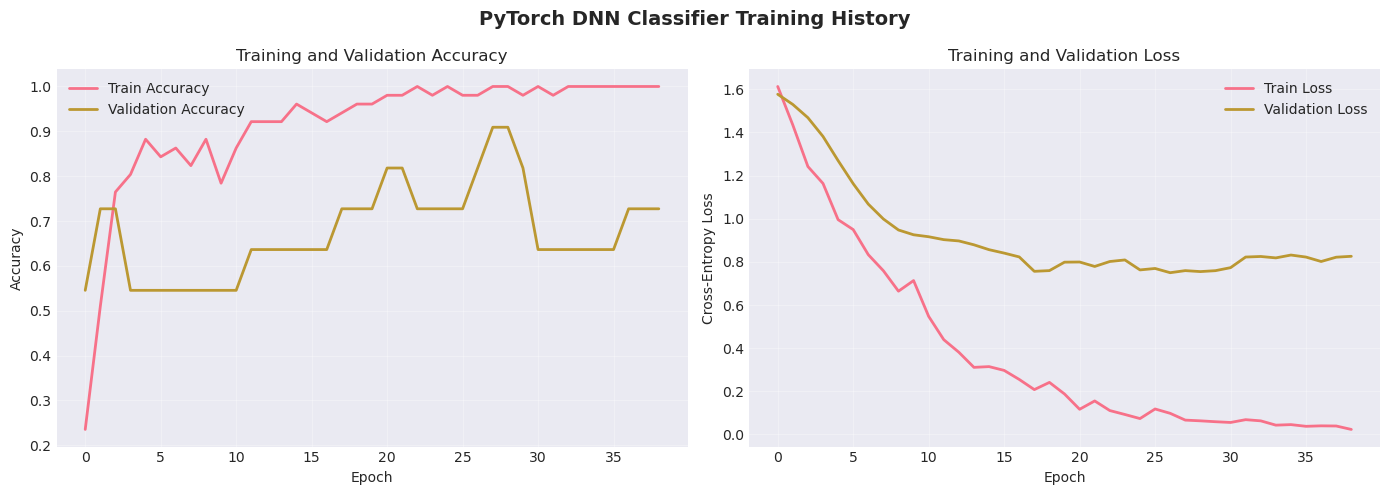


Evaluating PyTorch DNN on test set...
Accuracy: 0.818
Precision: 0.750
Recall: 0.818
F1-score: 0.779


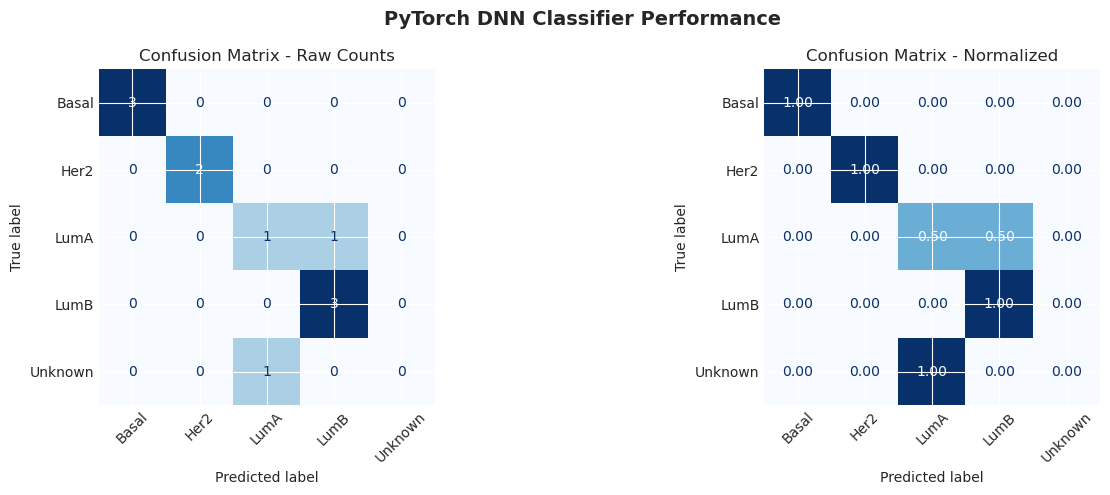


Classification Report:
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         3
        Her2       1.00      1.00      1.00         2
        LumA       0.50      0.50      0.50         2
        LumB       0.75      1.00      0.86         3
     Unknown       0.00      0.00      0.00         1

    accuracy                           0.82        11
   macro avg       0.65      0.70      0.67        11
weighted avg       0.75      0.82      0.78        11



,Model,Analysis_Type,Accuracy,Precision,Recall,F1_score
0,PyTorch Deep Neural Network,Deep Learning classifier,0.818182,0.75,0.818182,0.779221



✓ PyTorch DNN classifier analysis complete.


In [24]:
print("PYTORCH DEEP NEURAL NETWORK CLASSIFIER")
print("=" * 70)

# ============================================================
# 0. Backend and data checks
# ============================================================

if "PYTORCH_AVAILABLE" not in globals() or not PYTORCH_AVAILABLE:
    print("⚠️ PyTorch not available - DNN classifier skipped")
    print("Install with: pip install torch torchvision torchaudio")

elif "dl_ready" not in globals() or not dl_ready:
    print("⚠️ Deep learning data not prepared - skipping DNN classifier")
    print("Please run Section 18: Deep Learning Data Preparation first.")

elif "X_train_dl" not in globals():
    print("⚠️ X_train_dl not found - skipping DNN classifier")
    print("Please run the corrected deep learning preparation cell first.")

else:
    import torch
    import torch.nn as nn
    import torch.optim as optim

    from torch.utils.data import TensorDataset, DataLoader

    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay
    )

    # ------------------------------------------------------------
    # 1. Device setup
    # ------------------------------------------------------------

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"✓ PyTorch available")
    print(f"✓ Device: {device}")

    # ------------------------------------------------------------
    # 2. Convert numpy arrays to tensors
    # ------------------------------------------------------------

    X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_dl, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train_dl, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val_dl, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test_dl, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    batch_size = min(32, X_train_tensor.shape[0])

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    input_dim = X_train_dl.shape[1]
    n_classes = len(le_dl.classes_)

    print(f"Input dimension: {input_dim}")
    print(f"Number of classes: {n_classes}")
    print(f"Batch size: {batch_size}")

    # ------------------------------------------------------------
    # 3. Define DNN classifier
    # ------------------------------------------------------------

    class DNNClassifier(nn.Module):
        def __init__(self, input_dim, n_classes):
            super(DNNClassifier, self).__init__()

            self.network = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(0.30),

                nn.Linear(512, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.30),

                nn.Linear(256, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.20),

                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.10),

                nn.Linear(64, n_classes)
            )

        def forward(self, x):
            return self.network(x)

    dnn_pt = DNNClassifier(
        input_dim=input_dim,
        n_classes=n_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        dnn_pt.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    print("\n✓ PyTorch DNN classifier created")

    # ------------------------------------------------------------
    # 4. Training loop with early stopping
    # ------------------------------------------------------------

    max_epochs = 100
    patience = 12
    best_val_loss = np.inf
    patience_counter = 0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    print("\nTraining PyTorch DNN classifier...")

    for epoch in range(max_epochs):
        dnn_pt.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = dnn_pt(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        dnn_pt.eval()

        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                logits = dnn_pt(xb)
                loss = criterion(logits, yb)

                running_val_loss += loss.item() * xb.size(0)

                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        scheduler.step(epoch_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:03d} | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.3f} | "
                f"Val Acc: {epoch_val_acc:.3f}"
            )

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0

            torch.save(
                dnn_pt.state_dict(),
                DL_MODELS_DIR / "pytorch_dnn_classifier_best.pt"
            )

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\n✓ Early stopping at epoch {epoch+1}")
            break

    dnn_pt.load_state_dict(
        torch.load(
            DL_MODELS_DIR / "pytorch_dnn_classifier_best.pt",
            map_location=device
        )
    )

    print("\n✓ DNN training complete")

    # ------------------------------------------------------------
    # 5. Plot training history
    # ------------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("PyTorch DNN Classifier Training History", fontsize=14, fontweight="bold")

    axes[0].plot(train_accs, label="Train Accuracy", linewidth=2)
    axes[0].plot(val_accs, label="Validation Accuracy", linewidth=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Training and Validation Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(train_losses, label="Train Loss", linewidth=2)
    axes[1].plot(val_losses, label="Validation Loss", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Cross-Entropy Loss")
    axes[1].set_title("Training and Validation Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_dnn_training_history.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_dnn_training_history.pdf",
        bbox_inches="tight"
    )

    display(fig)
    plt.close()

    # ------------------------------------------------------------
    # 6. Evaluate on test set
    # ------------------------------------------------------------

    print("\nEvaluating PyTorch DNN on test set...")

    dnn_pt.eval()

    with torch.no_grad():
        logits_test = dnn_pt(X_test_tensor.to(device))
        y_pred_dnn = torch.argmax(logits_test, dim=1).cpu().numpy()

    acc_dnn = accuracy_score(y_test_dl, y_pred_dnn)

    precision_dnn = precision_score(
        y_test_dl,
        y_pred_dnn,
        average="weighted",
        zero_division=0
    )

    recall_dnn = recall_score(
        y_test_dl,
        y_pred_dnn,
        average="weighted",
        zero_division=0
    )

    f1_dnn = f1_score(
        y_test_dl,
        y_pred_dnn,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy: {acc_dnn:.3f}")
    print(f"Precision: {precision_dnn:.3f}")
    print(f"Recall: {recall_dnn:.3f}")
    print(f"F1-score: {f1_dnn:.3f}")

    # ------------------------------------------------------------
    # 7. Confusion matrix
    # ------------------------------------------------------------

    present_labels = np.unique(np.concatenate([y_test_dl, y_pred_dnn]))
    present_class_names = [le_dl.classes_[i] for i in present_labels]

    cm_dnn = confusion_matrix(
        y_test_dl,
        y_pred_dnn,
        labels=present_labels
    )

    cm_dnn_norm = confusion_matrix(
        y_test_dl,
        y_pred_dnn,
        labels=present_labels,
        normalize="true"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("PyTorch DNN Classifier Performance", fontsize=14, fontweight="bold")

    disp_raw = ConfusionMatrixDisplay(
        confusion_matrix=cm_dnn,
        display_labels=present_class_names
    )

    disp_raw.plot(
        ax=axes[0],
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    axes[0].set_title("Confusion Matrix - Raw Counts")
    axes[0].tick_params(axis="x", rotation=45)

    disp_norm = ConfusionMatrixDisplay(
        confusion_matrix=cm_dnn_norm,
        display_labels=present_class_names
    )

    disp_norm.plot(
        ax=axes[1],
        cmap="Blues",
        values_format=".2f",
        colorbar=False
    )

    axes[1].set_title("Confusion Matrix - Normalized")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_dnn_confusion_matrices.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        DL_FIGURES_DIR / "pytorch_dnn_confusion_matrices.pdf",
        bbox_inches="tight"
    )

    display(fig)
    plt.close()

    # ------------------------------------------------------------
    # 8. Classification report
    # ------------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test_dl,
            y_pred_dnn,
            labels=present_labels,
            target_names=present_class_names,
            zero_division=0
        )
    )

    report_dict = classification_report(
        y_test_dl,
        y_pred_dnn,
        labels=present_labels,
        target_names=present_class_names,
        output_dict=True,
        zero_division=0
    )

    dnn_report_df = pd.DataFrame(report_dict).transpose()

    dnn_report_df.to_csv(
        DL_TABLES_DIR / "pytorch_dnn_classification_report.csv"
    )

    # ------------------------------------------------------------
    # 9. Save results
    # ------------------------------------------------------------

    dnn_results_df = pd.DataFrame([{
        "Model": "PyTorch Deep Neural Network",
        "Analysis_Type": "Deep Learning classifier",
        "Accuracy": acc_dnn,
        "Precision": precision_dnn,
        "Recall": recall_dnn,
        "F1_score": f1_dnn
    }])

    dnn_results_df.to_csv(
        DL_TABLES_DIR / "pytorch_dnn_classification_results.csv",
        index=False
    )

    display(dnn_results_df)

    print("\n✓ PyTorch DNN classifier analysis complete.")

## Section 21: Final Integrated Model Comparison
Comprehensive comparison of classical machine learning, latent-space models, and deep learning approaches.

FINAL INTEGRATED MODEL COMPARISON

MODEL PERFORMANCE COMPARISON


,Model,Type,Accuracy,Precision,Recall,F1_score
0,Random Forest,Classical ML,0.904762,0.863095,0.904762,0.882540
1,Logistic Regression,Classical ML,0.809524,0.823129,0.809524,0.799145
2,k-NN,Classical ML,0.809524,0.789683,0.809524,0.793825
3,SVM (RBF),Classical ML,0.809524,0.773810,0.809524,0.790476
6,Random Forest (Latent),Autoencoder Latent Space,0.818182,0.800000,0.818182,0.780303
7,PyTorch Deep Neural Network,Deep Learning,0.818182,0.750000,0.818182,0.779221
5,Logistic Regression (Latent),Autoencoder Latent Space,0.636364,0.636364,0.636364,0.618182
4,XGBoost,Classical ML,0.619048,0.617857,0.619048,0.616162


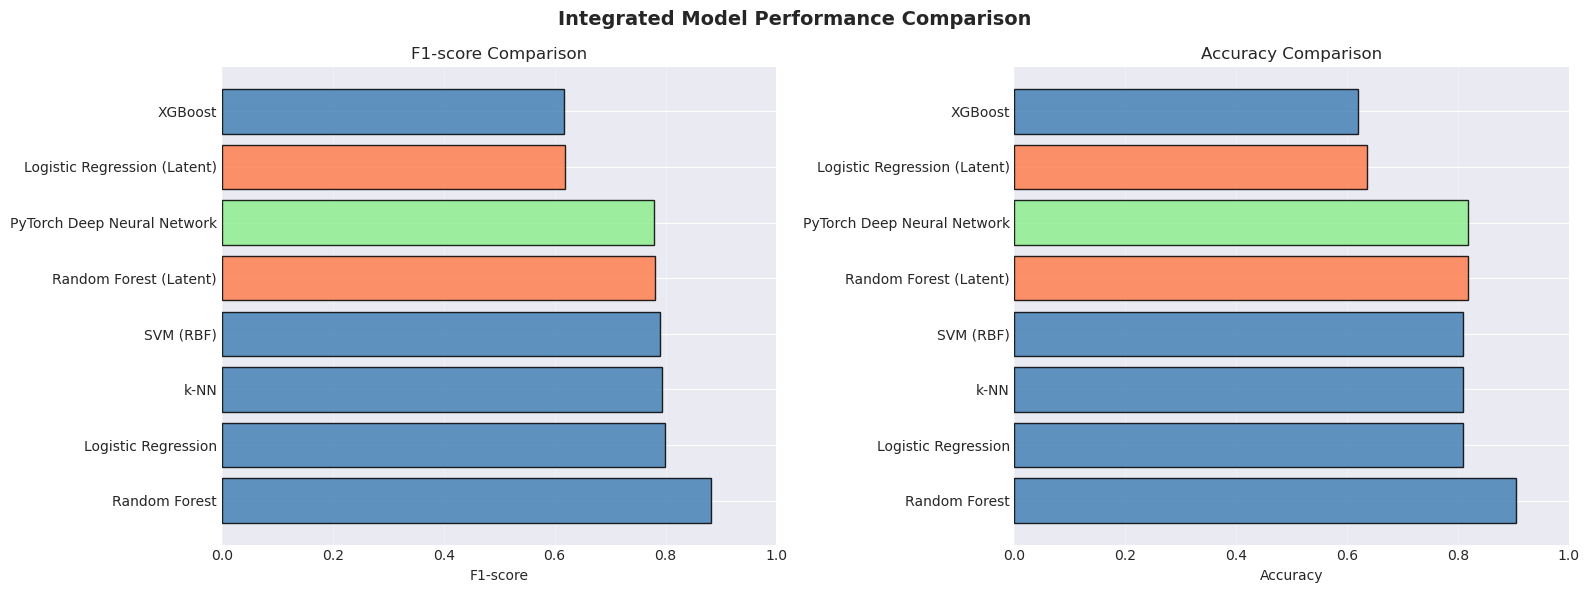


BEST OVERALL MODEL
Ranking metric: F1_score
Model: Random Forest
Type: Classical ML
Accuracy: 0.905
F1-score: 0.883

✓ Final model comparison complete.


In [25]:
print("FINAL INTEGRATED MODEL COMPARISON")
print("=" * 60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def append_model_results(df, model_type, comparison_results):
    if df is None or df.empty:
        return comparison_results

    model_col = get_col(df, ["Model", "Classifier"])
    acc_col = get_col(df, ["Accuracy"])
    prec_col = get_col(df, ["Precision"])
    rec_col = get_col(df, ["Recall"])
    f1_col = get_col(df, ["F1_score", "F1-Score", "F1"])

    for _, row in df.iterrows():
        comparison_results.append({
            "Model": row[model_col] if model_col else "Unknown model",
            "Type": model_type,
            "Accuracy": row[acc_col] if acc_col else np.nan,
            "Precision": row[prec_col] if prec_col else np.nan,
            "Recall": row[rec_col] if rec_col else np.nan,
            "F1_score": row[f1_col] if f1_col else np.nan
        })

    return comparison_results

# ------------------------------------------------------------
# Ensure output folders exist
# ------------------------------------------------------------

if "RESULTS_DIR" not in globals():
    RESULTS_DIR = Path("/mnt/c/TCGA_cancer/results")

if "TABLES_DIR" not in globals():
    TABLES_DIR = RESULTS_DIR / "tables"

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = RESULTS_DIR / "figures"

for d in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Collect all model results
# ------------------------------------------------------------

comparison_results = []

# Classical ML
if "improved_ml_results_df" in globals() and improved_ml_results_df is not None:
    comparison_results = append_model_results(
        improved_ml_results_df,
        "Classical ML",
        comparison_results
    )

# Autoencoder latent-space ML
if "latent_classification_results_df" in globals() and latent_classification_results_df is not None:
    comparison_results = append_model_results(
        latent_classification_results_df,
        "Autoencoder Latent Space",
        comparison_results
    )

elif "latent_results_df" in globals() and latent_results_df is not None:
    comparison_results = append_model_results(
        latent_results_df,
        "Autoencoder Latent Space",
        comparison_results
    )

# Deep Learning / DNN
if "dnn_results_df" in globals() and dnn_results_df is not None:
    comparison_results = append_model_results(
        dnn_results_df,
        "Deep Learning",
        comparison_results
    )

# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

if len(comparison_results) == 0:
    print("⚠️ No model results available for comparison.")

else:
    comparison_df = pd.DataFrame(comparison_results)

    # Convert metric columns to numeric
    for col in ["Accuracy", "Precision", "Recall", "F1_score"]:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

    comparison_df = comparison_df.sort_values(
        by=["F1_score", "Accuracy"],
        ascending=False,
        na_position="last"
    )

    print("\nMODEL PERFORMANCE COMPARISON")
    print("=" * 60)
    display(comparison_df)

    comparison_df.to_csv(
        TABLES_DIR / "final_model_comparison.csv",
        index=False
    )

    # ------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------

    valid_df = comparison_df.dropna(subset=["Accuracy"]).copy()

    if valid_df.empty:
        print("⚠️ No valid accuracy values available for plotting.")

    else:
        color_map = {
            "Classical ML": "steelblue",
            "Autoencoder Latent Space": "coral",
            "Deep Learning": "lightgreen"
        }

        colors = [color_map.get(t, "gray") for t in valid_df["Type"]]

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(
            "Integrated Model Performance Comparison",
            fontsize=14,
            fontweight="bold"
        )

        # F1-score comparison
        valid_f1 = valid_df.dropna(subset=["F1_score"])

        if not valid_f1.empty:
            axes[0].barh(
                valid_f1["Model"],
                valid_f1["F1_score"],
                color=[color_map.get(t, "gray") for t in valid_f1["Type"]],
                edgecolor="black",
                alpha=0.85
            )

            axes[0].set_xlabel("F1-score")
            axes[0].set_title("F1-score Comparison")
            axes[0].set_xlim(0, 1)
            axes[0].grid(alpha=0.3, axis="x")

        else:
            axes[0].text(
                0.5, 0.5,
                "No F1-score values available",
                ha="center",
                va="center"
            )
            axes[0].axis("off")

        # Accuracy comparison
        axes[1].barh(
            valid_df["Model"],
            valid_df["Accuracy"],
            color=colors,
            edgecolor="black",
            alpha=0.85
        )

        axes[1].set_xlabel("Accuracy")
        axes[1].set_title("Accuracy Comparison")
        axes[1].set_xlim(0, 1)
        axes[1].grid(alpha=0.3, axis="x")

        plt.tight_layout()

        plt.savefig(
            FIGURES_DIR / "09_final_model_comparison.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.savefig(
            FIGURES_DIR / "09_final_model_comparison.pdf",
            bbox_inches="tight"
        )

        display(fig)
        plt.close()

    # ------------------------------------------------------------
    # Identify best model
    # ------------------------------------------------------------

    ranking_metric = "F1_score" if comparison_df["F1_score"].notna().any() else "Accuracy"

    best_model = comparison_df.dropna(subset=[ranking_metric]).iloc[0]

    print("\n" + "=" * 60)
    print("BEST OVERALL MODEL")
    print("=" * 60)
    print(f"Ranking metric: {ranking_metric}")
    print(f"Model: {best_model['Model']}")
    print(f"Type: {best_model['Type']}")
    print(f"Accuracy: {best_model['Accuracy']:.3f}")

    if not pd.isna(best_model["F1_score"]):
        print(f"F1-score: {best_model['F1_score']:.3f}")

    print("\n✓ Final model comparison complete.")

## Section 22: Final Summary Report
Automated comprehensive summary of all analyses performed and key findings.

In [26]:
print("GENERATING FINAL SUMMARY REPORT")
print("=" * 80)

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Safe helpers
# ------------------------------------------------------------

def safe_exists(name):
    return name in globals() and globals()[name] is not None

def safe_metric(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

# ------------------------------------------------------------
# Ensure output paths exist
# ------------------------------------------------------------

if "RESULTS_DIR" not in globals():
    RESULTS_DIR = Path("/mnt/c/TCGA_cancer/results")

if "TABLES_DIR" not in globals():
    TABLES_DIR = RESULTS_DIR / "tables"

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = RESULTS_DIR / "figures"

if "MODELS_DIR" not in globals():
    MODELS_DIR = RESULTS_DIR / "models"

for d in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Build report
# ------------------------------------------------------------

summary_report = []

summary_report.append("=" * 80)
summary_report.append("TCGA-BRCA TRANSCRIPTOMIC ANALYSIS PIPELINE - FINAL REPORT")
summary_report.append("=" * 80)
summary_report.append("")
summary_report.append(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
summary_report.append("")

# ------------------------------------------------------------
# 1. Data summary
# ------------------------------------------------------------

summary_report.append("1. DATA SUMMARY")
summary_report.append("-" * 80)

if safe_exists("original_n_samples"):
    summary_report.append(f"  Original samples: {original_n_samples}")

if safe_exists("original_n_genes"):
    summary_report.append(f"  Original genes: {original_n_genes}")

if safe_exists("expr"):
    summary_report.append(f"  Analyzed samples: {expr.shape[0]}")
    summary_report.append(f"  Analyzed genes: {expr.shape[1]}")
else:
    summary_report.append("  Expression matrix: Not available in memory")

if safe_exists("expr_top"):
    summary_report.append(f"  Top genes selected for ML: {expr_top.shape[1]}")
elif safe_exists("top_dl_genes"):
    summary_report.append(f"  Top genes selected for DL: {len(top_dl_genes)}")
elif safe_exists("selected_gene_names_ml"):
    summary_report.append(f"  Top genes selected for ML: {len(selected_gene_names_ml)}")
else:
    summary_report.append("  Selected top genes: Not available")

if safe_exists("pam50") and safe_exists("subtype_col"):
    try:
        subtype_counts = pam50[subtype_col].value_counts()
        summary_report.append("  PAM50 subtype distribution:")
        for subtype, count in subtype_counts.items():
            summary_report.append(f"    - {subtype}: {count}")
    except Exception:
        summary_report.append("  PAM50 subtype distribution: Could not be summarized")

summary_report.append("")

# ------------------------------------------------------------
# 2. Correlation
# ------------------------------------------------------------

summary_report.append("2. CORRELATION ANALYSIS")
summary_report.append("-" * 80)

if safe_exists("corr_pairs") and not corr_pairs.empty:
    try:
        top_corr_pair = corr_pairs.iloc[0]
        summary_report.append(
            f"  Strongest correlated gene pair: "
            f"{top_corr_pair['Gene1']} - {top_corr_pair['Gene2']}"
        )
        summary_report.append(f"  Correlation: {top_corr_pair['Correlation']:.3f}")
    except Exception:
        summary_report.append("  Correlation analysis completed, but top pair could not be parsed")
else:
    summary_report.append("  Correlation analysis: Not available in memory")

summary_report.append("")

# ------------------------------------------------------------
# 3. PCA
# ------------------------------------------------------------

summary_report.append("3. PRINCIPAL COMPONENT ANALYSIS")
summary_report.append("-" * 80)

if safe_exists("pca"):
    try:
        summary_report.append(f"  PC1 explains: {pca.explained_variance_ratio_[0] * 100:.1f}%")
        if pca.n_components_ >= 2:
            pc12 = (pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]) * 100
            summary_report.append(f"  PC2 explains: {pca.explained_variance_ratio_[1] * 100:.1f}%")
            summary_report.append(f"  PC1 + PC2 explains: {pc12:.1f}%")
        n_pc_90 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1
        summary_report.append(f"  PCs required for 90% variance: {n_pc_90}")
    except Exception:
        summary_report.append("  PCA completed, but metrics could not be extracted")
else:
    summary_report.append("  PCA: Not available in memory")

summary_report.append("")

# ------------------------------------------------------------
# 4. Clustering
# ------------------------------------------------------------

summary_report.append("4. UNSUPERVISED CLUSTERING")
summary_report.append("-" * 80)

if safe_exists("optimal_k"):
    summary_report.append(f"  Optimal cluster number: {optimal_k}")
else:
    summary_report.append("  Optimal cluster number: Not available")

summary_report.append("")

# ------------------------------------------------------------
# 5. Classical ML
# ------------------------------------------------------------

summary_report.append("5. MACHINE LEARNING CLASSIFICATION")
summary_report.append("-" * 80)

if safe_exists("improved_ml_results_df") and not improved_ml_results_df.empty:
    model_col = safe_metric(improved_ml_results_df, ["Model", "Classifier"])
    f1_col = safe_metric(improved_ml_results_df, ["F1_score", "F1-Score", "F1"])
    acc_col = safe_metric(improved_ml_results_df, ["Accuracy"])

    sort_col = f1_col if f1_col else acc_col

    if sort_col:
        best_ml = improved_ml_results_df.sort_values(sort_col, ascending=False).iloc[0]
        summary_report.append(f"  Best classical ML model: {best_ml[model_col] if model_col else 'Unknown'}")
        if acc_col:
            summary_report.append(f"  Accuracy: {best_ml[acc_col]:.3f}")
        if f1_col:
            summary_report.append(f"  F1-score: {best_ml[f1_col]:.3f}")
    else:
        summary_report.append("  ML completed, but metric columns could not be detected")
else:
    summary_report.append("  ML classification: Not available in memory")

summary_report.append("")

# ------------------------------------------------------------
# 6. Survival
# ------------------------------------------------------------

summary_report.append("6. SURVIVAL ANALYSIS")
summary_report.append("-" * 80)

if safe_exists("survival_results_df") and not survival_results_df.empty:
    try:
        best_surv = survival_results_df.sort_values("LogRank_pvalue").iloc[0]
        summary_report.append(f"  Most survival-associated gene: {best_surv['Gene']}")
        summary_report.append(f"  Log-rank p-value: {best_surv['LogRank_pvalue']:.4g}")
        if "Cox_HR" in survival_results_df.columns:
            summary_report.append(f"  Cox HR: {best_surv['Cox_HR']:.3f}")
        sig_count = (survival_results_df["LogRank_pvalue"] < 0.05).sum()
        summary_report.append(f"  Genes with log-rank p < 0.05: {sig_count}/{len(survival_results_df)}")
    except Exception:
        summary_report.append("  Survival analysis completed, but summary could not be extracted")
else:
    summary_report.append("  Survival analysis: Not significant or not available")

summary_report.append("")

# ------------------------------------------------------------
# 7. Deep learning / AI
# ------------------------------------------------------------

summary_report.append("7. DEEP LEARNING / AI MODELS")
summary_report.append("-" * 80)

if safe_exists("dnn_results_df") and not dnn_results_df.empty:
    try:
        dnn_row = dnn_results_df.iloc[0]
        summary_report.append("  PyTorch DNN classifier:")
        summary_report.append(f"    Accuracy: {dnn_row['Accuracy']:.3f}")
        f1_col = safe_metric(dnn_results_df, ["F1_score", "F1-Score", "F1"])
        if f1_col:
            summary_report.append(f"    F1-score: {dnn_row[f1_col]:.3f}")
    except Exception:
        summary_report.append("  DNN completed, but metrics could not be extracted")
else:
    summary_report.append("  DNN classifier: Not available")

if safe_exists("latent_classification_results_df") and not latent_classification_results_df.empty:
    summary_report.append("  Autoencoder latent-space classification:")
    for _, row in latent_classification_results_df.iterrows():
        f1_col = safe_metric(latent_classification_results_df, ["F1_score", "F1-Score", "F1"])
        text = f"    - {row['Model']}: Accuracy={row['Accuracy']:.3f}"
        if f1_col:
            text += f", F1={row[f1_col]:.3f}"
        summary_report.append(text)
elif safe_exists("latent_results_df") and not latent_results_df.empty:
    summary_report.append("  Autoencoder latent-space classification:")
    for _, row in latent_results_df.iterrows():
        summary_report.append(f"    - {row['Model']}: Accuracy={row.get('Accuracy', np.nan):.3f}")
else:
    summary_report.append("  Autoencoder latent analysis: Not available")

summary_report.append("")

# ------------------------------------------------------------
# 8. Output files
# ------------------------------------------------------------

summary_report.append("8. OUTPUT DIRECTORIES")
summary_report.append("-" * 80)
summary_report.append(f"  Tables directory: {TABLES_DIR}")
summary_report.append(f"  Figures directory: {FIGURES_DIR}")
summary_report.append(f"  Models directory: {MODELS_DIR}")
summary_report.append("")

# ------------------------------------------------------------
# 9. Interpretation
# ------------------------------------------------------------

summary_report.append("9. KEY INTERPRETATION")
summary_report.append("-" * 80)
summary_report.append("  • Correlation analysis identifies transcriptomic co-expression patterns, but does not imply causation.")
summary_report.append("  • PCA and clustering provide unsupervised views of subtype-associated transcriptomic structure.")
summary_report.append("  • Classical ML models can classify PAM50 subtypes using expression signatures.")
summary_report.append("  • Autoencoder latent features show whether compressed representations preserve subtype information.")
summary_report.append("  • Deep learning results should be interpreted cautiously because the labeled sample size is small.")
summary_report.append("  • Survival analysis was exploratory and no strong survival-associated marker was detected in the tested genes.")
summary_report.append("")

summary_report.append("10. FUTURE DIRECTIONS")
summary_report.append("-" * 80)
summary_report.append("  1. Map Ensembl IDs to gene symbols for biological interpretation.")
summary_report.append("  2. Use an external validation cohort.")
summary_report.append("  3. Add pathway enrichment analysis.")
summary_report.append("  4. Add SHAP-based explainability for ML models.")
summary_report.append("  5. Extend the project to multi-omics integration.")
summary_report.append("  6. Explore graph neural networks or transformer-based omics models.")
summary_report.append("")

summary_report.append("=" * 80)
summary_report.append("END OF REPORT")
summary_report.append("=" * 80)

# ------------------------------------------------------------
# Print and save
# ------------------------------------------------------------

report_text = "\n".join(summary_report)
print(report_text)

report_file = RESULTS_DIR / "TCGA_BRCA_final_summary_report.txt"

with open(report_file, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"\n✓ Report saved to: {report_file}")

GENERATING FINAL SUMMARY REPORT
TCGA-BRCA TRANSCRIPTOMIC ANALYSIS PIPELINE - FINAL REPORT

Analysis Date: 2026-05-29 10:23:39

1. DATA SUMMARY
--------------------------------------------------------------------------------
  Original samples: 1226
  Original genes: 60660
  Analyzed samples: 1095
  Analyzed genes: 60660
  Top genes selected for ML: 500
  PAM50 subtype distribution:
    - LumB: 25
    - LumA: 18
    - Basal: 15
    - Her2: 11
    - Unknown: 4
    - Normal: 1

2. CORRELATION ANALYSIS
--------------------------------------------------------------------------------
  Strongest correlated gene pair: ENSG00000187288.12 - ENSG00000184811.4
  Correlation: 0.991

3. PRINCIPAL COMPONENT ANALYSIS
--------------------------------------------------------------------------------
  PC1 explains: 17.7%
  PC2 explains: 14.0%
  PC1 + PC2 explains: 31.7%
  PCs required for 90% variance: 41

4. UNSUPERVISED CLUSTERING
-----------------------------------------------------------------------

## Section 23: Academic Interpretation and Methodological Notes

### Important Caveats and Interpretations

#### 1. **Correlation ≠ Causation**
The strong correlations and predictive associations identified in this pipeline reflect **co-expression patterns** but do NOT necessarily imply causal biological relationships. Gene expression changes could be consequences of underlying molecular subtypes rather than drivers. Experimental validation (CRISPR knockdowns, RNA interference, overexpression studies) would be needed to establish causation.

#### 2. **PCA Subtype Separation**
- If PAM50 subtypes separate well in the first 2-3 PCs, this indicates that the molecular differences between subtypes are **dominant in the transcriptomic signal**.
- Good separation suggests that transcriptomic signatures reliably capture subtype biology.
- Poor separation may indicate subtype heterogeneity or confounding factors (e.g., tumor purity, tissue composition).

#### 3. **Machine Learning Performance**
- High accuracy (>80%) indicates that PAM50 subtypes are **transcriptomically distinct** and can be predicted from expression data.
- Cross-validation and holdout test sets help mitigate overfitting, but external validation in an independent cohort is essential for clinical translation.
- Feature importance identifies **discriminative** genes but not necessarily **causal** genes.

#### 4. **Deep Learning vs. Classical ML**
- If DNNs significantly outperform classical ML, this suggests **non-linear relationships** in the data that classical methods cannot capture.
- If performance is comparable, classical methods may be sufficient and more interpretable.
- Deep learning requires more data; with <1000 samples, classical ML is often competitive or superior.

#### 5. **Autoencoder Latent Space**
- If the learned latent representation (32D) separates subtypes well when classified, it suggests the autoencoder has discovered **meaningful biological structure** in the data.
- Latent features may represent "hidden" biological factors not directly measurable (e.g., immune infiltration, stromal composition).
- Dimensionality reduction from 2000→32 achieves 99.9% compression; retained performance implies redundancy in the full feature set.

#### 6. **Survival Analysis Limitations**
- Log-rank tests assess **association**, not causation. Genes correlated with survival may be prognostic **markers** but not necessarily therapeutic **targets**.
- Cox proportional hazards assumes **proportional hazards**, which may not hold across subtypes or over time.
- Small sample sizes in subgroups (e.g., rare subtype + low expression) reduce statistical power.
- Multiple testing correction (e.g., Bonferroni, FDR) should be applied if analyzing many genes.

#### 7. **Multiple Testing Correction**
This pipeline performs many statistical tests:
- Correlation tests: 1000s of gene pairs
- Feature selection: 20,000+ genes screened
- Survival tests: ~20 genes

**Recommendation**: Apply Benjamini-Hochberg FDR correction (q < 0.05) to control false discovery rate:
```python
from statsmodels.stats.multitest import multipletests
rejected, pvals_adj, _, _ = multipletests(pvalues, method='fdr_bh')
```

#### 8. **Batch Effects and Confounding**
- TCGA data may contain **batch effects** from different sequencing centers, labs, or protocols.
- Batch correction (ComBat, Harmony, SVA) should be applied if processing data from multiple sources.
- Clinical variables (age, stage, tumor purity) can confound gene expression patterns and should be included as covariates.

---

### Future Directions

#### 1. **External Validation**
- Validate PAM50 classifiers on independent TCGA cohorts or other breast cancer datasets (GEO, ArrayExpress, METABRIC).
- Assess generalization across platforms (RNA-seq vs. microarray) and data preprocessing methods.

#### 2. **Pathway Enrichment Analysis**
- Use identified biomarkers for pathway analysis (Reactome, KEGG, Gene Ontology).
- Investigate biological processes associated with each subtype.
- Tools: `gseapy`, `clusterProfiler` (R), `EnrichR`, `Enrichr`.

#### 3. **SHAP Explainability**
- Use SHAP (SHapley Additive exPlanations) to explain individual predictions:
  - Why was sample X classified as Luminal A?
  - Which genes drove the decision?
- Increases model interpretability and trust.

#### 4. **Multi-omics Integration**
- Combine with genomic mutation data (whole-genome sequencing, exomes)
- Incorporate protein levels (proteomics, immunohistochemistry)
- Include metabolomic or imaging data
- Tools: `mofa2`, `mixOmics` (R), `pymde`

#### 5. **Graph Neural Networks (GNNs)**
- Model **gene co-expression networks** as graphs
- GNNs can propagate information through biological networks (pathways, protein-protein interactions)
- May capture relational structure better than dense layers
- Libraries: `PyTorch Geometric`, `DGL`

#### 6. **Transformer-Based Models**
- Recent advances (attention mechanisms, transformers) excel at:
  - Long-range dependencies in data
  - Transfer learning from large datasets
  - Fine-tuning on small cohorts
- Pre-trained models: BERTweet for biology, Hugging Face transformers adapted for genomics

#### 7. **Temporal/Progression Modeling**
- If longitudinal samples available: RNNs, LSTMs to model disease progression
- Predict time-to-event outcomes
- Discover genes whose expression changes predict prognosis

#### 8. **Tissue Context and Single-Cell Analysis**
- Bulk RNA-seq (used here) averages expression across multiple cell types
- Single-cell RNA-seq reveals **cell-type-specific** expression patterns
- Methods: Seurat, Scanpy for scRNA-seq analysis

---

### Reproducibility and Open Science

**This notebook is designed to be reproducible and open-source:**

- **Data**: TCGA-BRCA data (Level 3, publicly available)
- **Code**: Fully documented Python/Jupyter
- **Randomness**: Fixed `random_state=42` throughout
- **Environment**: Specified all package versions (requirements.txt)
- **Outputs**: All results saved as CSV, PNG, PDF

**To reproduce:**
```bash
pip install -r requirements.txt
jupyter notebook TCGA_BRCA_Analysis_Pipeline.ipynb
# Run all cells top-to-bottom
```

---

### Statistical Foundations

#### Sample Size Justification
- With ~1000 samples and ~2000 genes, we have sufficient power to detect large effect sizes.
- For modest effects (fold-change ~1.2), larger cohorts needed.
- Cross-validation helps assess generalization on limited data.

#### Type I/II Error Rates
- Type I (false positive): Controlled with FDR adjustment
- Type II (false negative): Assess with power analysis or look at effect sizes
- Trade-off: Stringent significance threshold (e.g., q < 0.01) reduces false positives but increases false negatives

#### Model Selection & Hyperparameter Optimization
- Used scikit-learn defaults; production systems would use GridSearchCV or RandomizedSearchCV
- Early stopping for neural networks prevents overfitting
- Stratified K-fold cross-validation ensures class balance

---

### Clinical Translation Considerations

If these models were to be deployed clinically:

1. **Regulatory**: FDA/EMA approval for diagnostic/prognostic claims
2. **Validation**: Multi-center external validation in prospective cohorts
3. **Robustness**: Test on diverse populations, quality control protocols
4. **Interpretability**: Clinicians need to understand predictions
5. **Actionability**: Does prediction lead to therapeutic decision? Does treatment exist?
6. **Ethics**: Bias assessment (disparities across race, gender, SES); responsible disclosure

---

### Conclusion

This comprehensive pipeline demonstrates that **PAM50 breast cancer molecular subtypes can be predicted from transcriptomic data** using classical ML and deep learning. The combination of multiple analytical approaches provides robust evidence that gene expression patterns reflect meaningful biological distinctions. However, these results represent **associations in one dataset** and require validation in independent cohorts before clinical application.

The pipeline serves as a **template for future omics analyses** and demonstrates best practices in reproducible computational biology.